# CS 515 Final Project — Gaussian Grouping Pipeline
## Full pipeline: Frame extraction → COLMAP → SAM → DEVA → GG Training (30k) → Object Removal & Colorization

**GPU recommendation:** L4 (22 GB VRAM) with High-RAM is sufficient for 200 frames at 1920×1080. A100 is faster but not required.

**Estimated runtimes on L4 High-RAM:**
- Frame extraction + resize: ~2–3 min
- COLMAP (GPU feature extraction): ~8–15 min for 200 frames
- SAM mask generation: ~10–15 min
- DEVA tracking: ~5–8 min
- GG Training 30k iters: ~2.5–3.5 hours
- Rendering + editing: ~10–20 min

**Key changes from original notebook:**
1. Extracts exactly 200 frames at 1920×1080 (50% of 4K) and saves to Google Drive for group sharing
2. COLMAP data saved separately to Drive so teammates running vanilla 3D-GS and Mip-Splatting can reuse it
3. Training runs for 30k iterations (paper default) with checkpoint saves every 5k iters
4. Object colorization and removal cells added at the end

**Folder structure on your Drive after running:**
```
CS515_FinalProject/
  shared_data/           ← Share this folder with your group!
    frames/              ← 200 frames at 1920x1080 (for 3DGS & Mip-Splat)
    colmap/              ← COLMAP sparse reconstruction (cameras, points)
    masks/               ← SAM masks
    deva_masks/          ← DEVA tracked masks
  results/
    gg_output/           ← Gaussian Grouping checkpoints every 5k iters
```

## Step 0 — Mount Google Drive & Set Paths
Run this first. All data will be saved to Drive so nothing is lost if the Colab session disconnects.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT      = '/content/drive/MyDrive/CS515_FinalProject'
SHARED_DATA  = os.path.join(PROJECT, 'shared_data')      # share with teammates
FRAMES_DIR   = os.path.join(SHARED_DATA, 'frames')       # extracted 1920x1080 frames
COLMAP_DIR   = os.path.join(SHARED_DATA, 'colmap')       # COLMAP sparse output
MASKS_DIR    = os.path.join(SHARED_DATA, 'masks')        # SAM masks
DEVA_DIR     = os.path.join(SHARED_DATA, 'deva_masks')   # DEVA tracked masks
RESULTS_DIR  = os.path.join(PROJECT, 'results', 'gg_output')
GG_DIR       = os.path.join(PROJECT, 'gaussian-grouping')

# Local fast-disk workspace (lost on session end, but we back up to Drive)
SCENE_DIR    = '/content/scenes/my_scene'
INPUT_DIR    = os.path.join(SCENE_DIR, 'input')          # local copy of frames
UNDIST_DIR   = os.path.join(SCENE_DIR, 'undistorted')
OUTPUT_DIR   = os.path.join(SCENE_DIR, 'output')

for d in [SHARED_DATA, FRAMES_DIR, COLMAP_DIR, MASKS_DIR, DEVA_DIR,
          RESULTS_DIR, INPUT_DIR, UNDIST_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

print('✅ Paths ready')
print(f'  Shared data (share with group): {SHARED_DATA}')
print(f'  GG results:                     {RESULTS_DIR}')
print(f'  GG repo:                        {GG_DIR}')

Mounted at /content/drive
✅ Paths ready
  Shared data (share with group): /content/drive/MyDrive/CS515_FinalProject/shared_data
  GG results:                     /content/drive/MyDrive/CS515_FinalProject/results/gg_output
  GG repo:                        /content/drive/MyDrive/CS515_FinalProject/gaussian-grouping


## Step 1 — GPU & Dependency Check
Confirm you have an L4 (or better) GPU before spending time on later steps.

In [2]:
import torch

print(f'PyTorch:       {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:           {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM:          {vram:.1f} GB')
    if vram < 16:
        print('⚠️  Less than 16 GB VRAM — consider switching to L4 or A100')
    else:
        print('✅ VRAM is sufficient for 30k training')

PyTorch:       2.10.0+cu128
CUDA available: True
GPU:           NVIDIA L4
VRAM:          23.7 GB
✅ VRAM is sufficient for 30k training


In [3]:
# Install all required Python packages
# ninja speeds up CUDA extension compilation
!pip install -q ninja plyfile==0.8.1 tqdm scipy opencv-python scikit-learn lpips Pillow wandb

# Ensure PyTorch matches the system CUDA (12.x on Colab)
!pip install -q --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

print('✅ Python packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 85.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 103.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 124.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 154.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 82.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 232.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 126.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 257.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 216.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 182.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
# ── RESTORE FROM DRIVE (run this if your session disconnected) ──────────────
# If COLMAP, SAM, and DEVA have already been run in a previous session,
# this cell copies everything from Drive back to local disk so all later
# cells (training, editing, rendering) work without re-running the pipeline.
#
# Safe to run even on a fresh session — it skips steps that aren't on Drive yet.

import shutil, os

def restore(label, drive_src, local_dst):
    if not os.path.exists(drive_src):
        print(f'  ⏭  {label}: not on Drive yet — will be created when you run that step')
        return False
    if os.path.exists(local_dst):
        print(f'  ✅ {label}: already on local disk — skipping copy')
        return True
    print(f'  📥 {label}: copying from Drive to local ...', end=' ')
    if os.path.isdir(drive_src):
        shutil.copytree(drive_src, local_dst)
    else:
        os.makedirs(os.path.dirname(local_dst), exist_ok=True)
        shutil.copy(drive_src, local_dst)
    print('done')
    return True

print('=== Restoring data from Google Drive to local disk ===\n')

# 1. Frames (undistorted images — needed by training and SAM)
restore('Undistorted frames (COLMAP output)',
        drive_src = COLMAP_DIR,               # shared_data/colmap/
        local_dst = UNDIST_DIR)               # /content/scenes/my_scene/undistorted

# 2. SAM masks
restore('SAM masks',
        drive_src = MASKS_DIR,               # shared_data/masks/
        local_dst = os.path.join(SCENE_DIR, 'masks_local'))

# 3. DEVA masks
restore('DEVA tracked masks',
        drive_src = DEVA_DIR,                # shared_data/deva_masks/
        local_dst = os.path.join(SCENE_DIR, 'deva_local'))

# 4. GG training output (checkpoints, renders)
restore('GG training output',
        drive_src = RESULTS_DIR,             # results/gg_output/
        local_dst = OUTPUT_DIR)              # /content/scenes/my_scene/output

print('\n=== Restore summary ===')
checks = {
    'Undistorted images' : os.path.join(UNDIST_DIR, 'images'),
    'COLMAP sparse'      : os.path.join(UNDIST_DIR, 'sparse'),
    'SAM masks'          : os.path.join(SCENE_DIR, 'masks_local'),
    'DEVA masks'         : os.path.join(SCENE_DIR, 'deva_local'),
    'GG checkpoint 30k'  : os.path.join(OUTPUT_DIR, 'point_cloud', 'iteration_5000'),
}
for label, path in checks.items():
    status = '✅' if os.path.exists(path) else '❌ missing'
    print(f'  {status}  {label}: {path}')

print('''
Next steps based on what is restored:
  • If COLMAP missing  → run Steps 2–3
  • If SAM missing     → run Step 5
  • If DEVA missing    → run Step 6
  • If GG ckpt missing → run Steps 4 & 7
  • If everything ✅   → skip straight to Step 8 (rendering / editing)
''')

=== Restoring data from Google Drive to local disk ===

  ✅ Undistorted frames (COLMAP output): already on local disk — skipping copy
  📥 SAM masks: copying from Drive to local ... done
  📥 DEVA tracked masks: copying from Drive to local ... done
  ✅ GG training output: already on local disk — skipping copy

=== Restore summary ===
  ❌ missing  Undistorted images: /content/scenes/my_scene/undistorted/images
  ❌ missing  COLMAP sparse: /content/scenes/my_scene/undistorted/sparse
  ✅  SAM masks: /content/scenes/my_scene/masks_local
  ✅  DEVA masks: /content/scenes/my_scene/deva_local
  ❌ missing  GG checkpoint 30k: /content/scenes/my_scene/output/point_cloud/iteration_5000

Next steps based on what is restored:
  • If COLMAP missing  → run Steps 2–3
  • If SAM missing     → run Step 5
  • If DEVA missing    → run Step 6
  • If GG ckpt missing → run Steps 4 & 7
  • If everything ✅   → skip straight to Step 8 (rendering / editing)



## Step 2 — Upload Your Video
Upload `IMG_3790.MOV` (or any `.MOV`/`.mp4`) to Colab using the file browser on the left, then set `VIDEO_PATH` below.

In [ ]:
import cv2, os
from PIL import Image

# ── CONFIG — change this to your actual upload path ────────────────────────
VIDEO_NAME = "IMG_3790.MOV"   # <-- CHANGE THIS to your actual filename
VIDEO_PATH = f"/content/drive/MyDrive/CS515_FinalProject/Data/{VIDEO_NAME}"
# VIDEO_PATH   = '/content/IMG_3790.MOV'   # adjust if you renamed the file
NUM_FRAMES   = 200                        # total frames to extract
TARGET_W     = 1920                       # 50% of 3840 (4K)
TARGET_H     = 1080                       # 50% of 2160 (4K)
# ───────────────────────────────────────────────────────────────────────────

assert os.path.exists(VIDEO_PATH), f'Video not found: {VIDEO_PATH}'

cap        = cv2.VideoCapture(VIDEO_PATH)
total_vid  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps        = cap.get(cv2.CAP_PROP_FPS)
duration_s = total_vid / fps

print(f'Video info:')
print(f'  Total frames : {total_vid}')
print(f'  FPS          : {fps:.1f}')
print(f'  Duration     : {duration_s:.1f} s  ({duration_s/60:.1f} min)')

# Sample NUM_FRAMES evenly across the entire video
step       = total_vid / NUM_FRAMES
indices    = [int(i * step) for i in range(NUM_FRAMES)]

print(f'\nExtracting {NUM_FRAMES} frames at {TARGET_W}x{TARGET_H} ...')

saved = 0
for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    if not ok:
        continue
    # OpenCV reads BGR → convert to RGB for Pillow
    frame_rgb  = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img        = Image.fromarray(frame_rgb)
    img_resized = img.resize((TARGET_W, TARGET_H), Image.LANCZOS)
    out_name   = f'frame_{saved:05d}.jpg'
    # Save to local fast disk (for COLMAP) AND to Drive (for group sharing)
    img_resized.save(os.path.join(INPUT_DIR,  out_name), quality=92)
    img_resized.save(os.path.join(FRAMES_DIR, out_name), quality=92)
    saved += 1

cap.release()
print(f'✅ Saved {saved} frames')
print(f'   Local:  {INPUT_DIR}')
print(f'   Drive:  {FRAMES_DIR}  ← share this with your group')

Video info:
  Total frames : 5350
  FPS          : 60.0
  Duration     : 89.2 s  (1.5 min)

Extracting 200 frames at 1920x1080 ...
✅ Saved 200 frames
   Local:  /content/scenes/my_scene/input
   Drive:  /content/drive/MyDrive/CS515_FinalProject/shared_data/frames  ← share this with your group


## Step 3 — COLMAP (Structure-from-Motion)
COLMAP figures out the 3D camera positions for every frame. The output sparse reconstruction (cameras + point cloud) will be saved to Drive so your teammates can reuse it for vanilla 3D-GS and Mip-Splatting without re-running COLMAP.

**Runtime on L4:** ~8–15 minutes with GPU feature extraction enabled.

In [ ]:
# Install COLMAP (includes GPU SIFT support on Colab)
!apt-get install -y -q colmap
!colmap help 2>&1 | head -3

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libamd2 libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libcamd2 libccolamd2 libceres2
  libcholmod3 libcolamd2 libcxsparse3 libdouble-conversion3 libevdev2
  libfreeimage3 libgflags2.2 libglew2.2 libgoogle-glog0v5 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libilmbase25 libinput-bin
  libinput10 libjxr0 libmd4c0 libmetis5 libmtdev1 libopenexr25 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libraw20
  librsvg2-common libspqr2 libsuitesparseconfig5 libwacom-bin libwacom-common
  libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0
  libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qt5-gtk-platformtheme qttranslations5-l10n
  session-migration
Suggested packages:
  glew-utils gvfs qt

In [ ]:
import os, shutil

DB_PATH    = os.path.join(SCENE_DIR, 'database.db')
SPARSE_DIR = os.path.join(SCENE_DIR, 'sparse')
os.environ['QT_QPA_PLATFORM'] = 'offscreen'

# ── Ensure INPUT_DIR has frames (copy from Drive if local disk was wiped) ──
frame_count = len([f for f in os.listdir(INPUT_DIR) if f.endswith('.jpg')]) if os.path.exists(INPUT_DIR) else 0
if frame_count == 0:
    print(f'⚠️  INPUT_DIR is empty — copying frames from Drive ({FRAMES_DIR}) ...')
    os.makedirs(INPUT_DIR, exist_ok=True)
    copied = 0
    for fname in sorted(os.listdir(FRAMES_DIR)):
        if fname.endswith('.jpg'):
            shutil.copy2(os.path.join(FRAMES_DIR, fname), os.path.join(INPUT_DIR, fname))
            copied += 1
    print(f'  ✅ Copied {copied} frames to {INPUT_DIR}')
    frame_count = copied

assert frame_count > 0, f'No frames found in {INPUT_DIR} or {FRAMES_DIR}. Re-run Step 2 first.'
print(f'Running COLMAP on {frame_count} frames ...')

# ── Clean any previous failed run ─────────────────────────────────────────
!rm -f "{DB_PATH}"
!rm -rf "{SPARSE_DIR}"
os.makedirs(f'{SPARSE_DIR}/0', exist_ok=True)

# Step 1 — Feature extraction  (CPU SIFT — GPU OpenGL context unavailable on Colab)
print('\n⏳ [1/4] Feature extraction ...')
!QT_QPA_PLATFORM=offscreen colmap feature_extractor \
    --database_path "{DB_PATH}" \
    --image_path    "{INPUT_DIR}" \
    --ImageReader.single_camera 1 \
    --SiftExtraction.use_gpu 0 \
    --SiftExtraction.max_image_size 1920 \
    --SiftExtraction.max_num_features 4096

# Step 2 — Sequential matching  (CPU)
print('\n⏳ [2/4] Sequential matching ...')
!QT_QPA_PLATFORM=offscreen colmap sequential_matcher \
    --database_path "{DB_PATH}" \
    --SiftMatching.use_gpu 0 \
    --SequentialMatching.overlap 15 \
    --SequentialMatching.loop_detection 1 \
    --SequentialMatching.loop_detection_num_images 20

# Step 3 — Sparse reconstruction
print('\n⏳ [3/4] Sparse reconstruction (mapper) ...')
!QT_QPA_PLATFORM=offscreen colmap mapper \
    --database_path  "{DB_PATH}" \
    --image_path     "{INPUT_DIR}" \
    --output_path    "{SPARSE_DIR}" \
    --Mapper.num_threads 8 \
    --Mapper.multiple_models 0

# Step 4 — Convert binary model to text
print('\n⏳ [4/4] Convert to TXT ...')
!QT_QPA_PLATFORM=offscreen colmap model_converter \
    --input_path  "{SPARSE_DIR}/0" \
    --output_path "{SPARSE_DIR}/0" \
    --output_type TXT

print('\n✅ COLMAP done!')
!ls -lh "{SPARSE_DIR}/0"

# ── Verify reconstruction succeeded ───────────────────────────────────────
expected = ['cameras.txt', 'images.txt', 'points3D.txt']
missing  = [f for f in expected if not os.path.exists(os.path.join(SPARSE_DIR, '0', f))]
if missing:
    print(f'\n❌ Reconstruction failed — missing: {missing}')
    print('   Check the mapper output above for warnings.')
else:
    print(f'\n✅ Sparse model verified — all 3 TXT files present in {SPARSE_DIR}/0')
    # Back up to Drive so teammates can reuse and so it survives session resets
    print('   Backing up sparse model to Drive ...')
    dst_sparse = os.path.join(COLMAP_DIR, 'sparse')
    if os.path.exists(dst_sparse):
        shutil.rmtree(dst_sparse)
    shutil.copytree(os.path.join(SPARSE_DIR), dst_sparse)
    print(f'   ✅ Saved to {dst_sparse}')

Streaming output truncated to the last 5000 lines.
    Residuals : 4858
   Parameters : 6
   Iterations : 8
         Time : 0.0352008 [s]
 Initial cost : 0.483192 [px]
   Final cost : 0.476989 [px]
  Termination : Convergence

  => Continued observations: 2351
  => Added observations: 1503

Bundle adjustment report
------------------------
    Residuals : 47756
   Parameters : 7589
   Iterations : 15
         Time : 0.288264 [s]
 Initial cost : 0.426955 [px]
   Final cost : 0.414832 [px]
  Termination : Convergence

  => Merged observations: 324
  => Completed observations: 185
  => Filtered observations: 77
  => Changed observations: 0.022249

Bundle adjustment report
------------------------
    Residuals : 48042
   Parameters : 7547
   Iterations : 3
         Time : 0.0786951 [s]
 Initial cost : 0.493968 [px]
   Final cost : 0.487662 [px]
  Termination : Convergence

  => Merged observations: 0
  => Completed observations: 11
  => Filtered observations: 8
  => Changed observations: 

In [ ]:
# Undistort images — this creates the canonical PINHOLE-camera dataset
# that both Gaussian Grouping and vanilla 3D-GS / Mip-Splatting expect.
print('⏳ Undistorting images ...')
!QT_QPA_PLATFORM=offscreen colmap image_undistorter \
    --image_path    "{INPUT_DIR}" \
    --input_path    "{SPARSE_DIR}/0" \
    --output_path   "{UNDIST_DIR}" \
    --output_type   COLMAP

# GG expects sparse/0/ subfolder inside the undistorted directory
import shutil
sparse_0 = os.path.join(UNDIST_DIR, 'sparse', '0')
os.makedirs(sparse_0, exist_ok=True)

# Convert undistorted sparse to TXT
!QT_QPA_PLATFORM=offscreen colmap model_converter \
    --input_path  "{UNDIST_DIR}/sparse" \
    --output_path "{UNDIST_DIR}/sparse" \
    --output_type TXT

for fname in ['cameras.bin','images.bin','points3D.bin',
              'cameras.txt','images.txt','points3D.txt']:
    src = os.path.join(UNDIST_DIR, 'sparse', fname)
    dst = os.path.join(sparse_0, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

print('\n✅ Undistortion done')
!ls -lh "{sparse_0}"

⏳ Undistorting images ...

Reading reconstruction

 => Reconstruction with 200 images and 79177 points

Image undistortion

Undistorting image [1/200]
Undistorting image [2/200]
Undistorting image [3/200]
Undistorting image [4/200]
Undistorting image [5/200]
Undistorting image [6/200]
Undistorting image [7/200]
Undistorting image [8/200]
Undistorting image [9/200]
Undistorting image [10/200]
Undistorting image [11/200]
Undistorting image [12/200]
Undistorting image [13/200]
Undistorting image [14/200]
Undistorting image [15/200]
Undistorting image [16/200]
Undistorting image [17/200]
Undistorting image [18/200]
Undistorting image [19/200]
Undistorting image [20/200]
Undistorting image [21/200]
Undistorting image [22/200]
Undistorting image [23/200]
Undistorting image [24/200]
Undistorting image [25/200]
Undistorting image [26/200]
Undistorting image [27/200]
Undistorting image [28/200]
Undistorting image [29/200]
Undistorting image [30/200]
Undistorting image [31/200]
Undistorting imag

In [ ]:
# ── SAVE COLMAP OUTPUT TO DRIVE (for group sharing) ────────────────────────
# Teammates running vanilla 3D-GS or Mip-Splatting can point directly
# to shared_data/colmap/ as their -s (source) argument.

import shutil, os

print('Saving COLMAP data to Google Drive ...')
# Copy the full undistorted folder structure to Drive
if os.path.exists(COLMAP_DIR):
    shutil.rmtree(COLMAP_DIR)
shutil.copytree(UNDIST_DIR, COLMAP_DIR)

print(f'✅ COLMAP data saved to Drive: {COLMAP_DIR}')
print('   Tell your group to use this path as -s in their training command.')
!du -sh "{COLMAP_DIR}"

Saving COLMAP data to Google Drive ...
✅ COLMAP data saved to Drive: /content/drive/MyDrive/CS515_FinalProject/shared_data/colmap
   Tell your group to use this path as -s in their training command.
414M	/content/drive/MyDrive/CS515_FinalProject/shared_data/colmap


## Step 4 — Clone Gaussian Grouping Repo & Build CUDA Extensions
The repo is cloned to Google Drive so it persists across sessions.

In [8]:
import os

if not os.path.exists(os.path.join(GG_DIR, 'train.py')):
    print('Cloning Gaussian Grouping repo ...')
    !git clone https://github.com/lkeab/gaussian-grouping.git "{GG_DIR}"
else:
    print('✅ Repo already cloned')

# Pull latest just in case
!cd "{GG_DIR}" && git pull --quiet

print('\n✅ Gaussian Grouping repo ready:', GG_DIR)

✅ Repo already cloned

✅ Gaussian Grouping repo ready: /content/drive/MyDrive/CS515_FinalProject/gaussian-grouping


In [9]:
import sys, os

BUILD_DIR = '/content/submodules_build'

# Clean and copy fresh from Drive
!rm -rf "{BUILD_DIR}"
os.makedirs(BUILD_DIR, exist_ok=True)
!cp -r "{GG_DIR}/submodules/diff-gaussian-rasterization" "{BUILD_DIR}/"
!cp -r "{GG_DIR}/submodules/simple-knn" "{BUILD_DIR}/"

# ── FIX 1: Patch simple-knn CUDA source for missing FLT_MAX definition ──
# simple_knn.cu uses FLT_MAX but doesn't include the header that defines it.
# This causes a compile error on newer CUDA toolchains.
!sed -i '1i #include <cfloat>' "{BUILD_DIR}/simple-knn/simple_knn.cu"
print("Patched simple_knn.cu with #include <cfloat>")

# ── FIX 2: Patch setup.py to use setuptools instead of removed distutils ──
!sed -i 's/from distutils.core import setup/from setuptools import setup/' \
    "{BUILD_DIR}/simple-knn/setup.py"
print("Patched setup.py: distutils → setuptools")

# Confirm both patches
!head -n 3 "{BUILD_DIR}/simple-knn/simple_knn.cu"
!head -n 3 "{BUILD_DIR}/simple-knn/setup.py"

# ── FIX 3: Use `python setup.py install` instead of pip ──
# pip's isolated build environment doesn't see CUDA headers from PyTorch.
# Running setup.py directly in the current environment works reliably.
PYTHON = sys.executable
print(f"\nUsing Python: {PYTHON}")

print('\nBuilding diff-gaussian-rasterization ...')
%cd /content/submodules_build/diff-gaussian-rasterization
!{PYTHON} setup.py install --quiet

print('\nBuilding simple-knn ...')
%cd /content/submodules_build/simple-knn
!{PYTHON} setup.py install --quiet

# ── FIX 4: Manually add installed .egg files to sys.path ──
# setup.py install places packages in .egg directories that Python doesn't
# automatically find in the current session without this step.
import glob, pkg_resources

eggs = glob.glob('/usr/local/lib/python3.12/dist-packages/*.egg')
for egg in eggs:
    if egg not in sys.path:
        sys.path.insert(0, egg)

pkg_resources.working_set.add_entry('/usr/local/lib/python3.12/dist-packages')

# ── Verify both modules are importable ──
import importlib
all_ok = True
for mod in ['diff_gaussian_rasterization', 'simple_knn']:
    try:
        m = importlib.import_module(mod)
        print(f'✅ {mod} imported from: {m.__file__}')
    except ImportError as e:
        print(f'❌ {mod} failed: {e}')
        all_ok = False

if all_ok:
    print('\n✅ All CUDA extensions ready — proceed to Step 5')
else:
    print('\n❌ One or more extensions failed — check output above')

Patched simple_knn.cu with #include <cfloat>
Patched setup.py: distutils → setuptools
#include <cfloat>
/*
 * Copyright (C) 2023, Inria
#
# Copyright (C) 2023, Inria
# GRAPHDECO research group, https://team.inria.fr/graphdeco

Using Python: /usr/bin/python3

Building diff-gaussian-rasterization ...
/content/submodules_build/diff-gaussian-rasterization
running install
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptool

/tmp/ipykernel_11912/1296777882.py:42: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import glob, pkg_resources


## Step 5 — SAM: Generate Per-Frame Segmentation Masks
SAM (Segment Anything Model) automatically segments every object in each frame. These 2D masks are later tracked across frames by DEVA and then lifted to 3D by Gaussian Grouping.

In [ ]:
# Install SAM
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

# Download SAM ViT-H checkpoint (~2.5 GB) — cached to Drive
SAM_CKPT = os.path.join(PROJECT, 'checkpoints', 'sam_vit_h_4b8939.pth')
os.makedirs(os.path.dirname(SAM_CKPT), exist_ok=True)

if not os.path.exists(SAM_CKPT):
    print('Downloading SAM ViT-H checkpoint (~2.5 GB) ...')
    !wget -q -O "{SAM_CKPT}" \
        https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
    print('✅ SAM checkpoint downloaded')
else:
    print('✅ SAM checkpoint already cached')

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/simple_knn-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/diff_gaussian_rasterization-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  Preparing metadata (setup.py) ... done
✅ SAM checkpoint downloaded


In [ ]:
# ── DIAGNOSE & FIX: Find undistorted images before running SAM ──────────────
# Run this cell if SAM fails with "No such file or directory" for the images.
# It scans Drive and local disk to find where the frames actually are,
# then sets UNDIST_IMAGES to the correct path for the SAM cell below.

import os, glob

print('=== Scanning for undistorted images ===\n')

# All candidate locations to check
candidates = [
    os.path.join(UNDIST_DIR, 'images'),
    os.path.join(UNDIST_DIR, 'images', 'images'),   # sometimes nested on restore
    UNDIST_DIR,                                       # images dumped at root
    os.path.join(COLMAP_DIR, 'images'),               # Drive colmap copy
    FRAMES_DIR,                                       # original extracted frames
    INPUT_DIR,                                        # local input frames
]

found_path = None
for path in candidates:
    if not os.path.exists(path):
        print(f'  ❌  {path}')
        continue
    jpgs = glob.glob(os.path.join(path, '*.jpg'))
    pngs = glob.glob(os.path.join(path, '*.png'))
    count = len(jpgs) + len(pngs)
    if count > 0:
        print(f'  ✅  {path}  →  {count} images found')
        if found_path is None:
            found_path = path   # use the first valid hit
    else:
        print(f'  ⚠️   {path}  →  exists but 0 images inside')

print()

if found_path is None:
    # Last resort: deep search under SCENE_DIR and COLMAP_DIR
    print('No images found in standard locations — doing deep search ...')
    for root, dirs, files in os.walk(SCENE_DIR):
        jpgs = [f for f in files if f.endswith('.jpg')]
        if jpgs:
            print(f'  📁 Found {len(jpgs)} .jpg files in: {root}')
            found_path = root
            break
    if found_path is None:
        for root, dirs, files in os.walk(COLMAP_DIR):
            jpgs = [f for f in files if f.endswith('.jpg')]
            if jpgs:
                print(f'  📁 Found {len(jpgs)} .jpg files in: {root}')
                found_path = root
                break

print()

if found_path:
    UNDIST_IMAGES = found_path
    print(f'✅ UNDIST_IMAGES set to: {UNDIST_IMAGES}')
    print(f'   ({len(glob.glob(os.path.join(UNDIST_IMAGES, "*.jpg"))) + len(glob.glob(os.path.join(UNDIST_IMAGES, "*.png")))} images ready for SAM)')

    # If images are on Drive but not local, copy them to the expected local path
    expected_local = os.path.join(UNDIST_DIR, 'images')
    if UNDIST_IMAGES != expected_local and not UNDIST_IMAGES.startswith('/content/drive') == False:
        if not os.path.exists(expected_local):
            print(f'\n📥 Copying images to expected local path for SAM ...')
            import shutil
            shutil.copytree(UNDIST_IMAGES, expected_local)
            UNDIST_IMAGES = expected_local
            print(f'✅ Copied to: {UNDIST_IMAGES}')
        else:
            UNDIST_IMAGES = expected_local
            print(f'   Local copy already exists at expected path')
else:
    print('❌ No images found anywhere!')
    print('   You need to re-run Steps 2–3 (frame extraction + COLMAP).')
    print(f'   Check if your Drive has frames at: {FRAMES_DIR}')
    UNDIST_IMAGES = None

# Also fix UNDIST_DIR sparse path while we're here
sparse_candidates = [
    os.path.join(UNDIST_DIR, 'sparse'),
    os.path.join(UNDIST_DIR, 'sparse', '0'),
    os.path.join(COLMAP_DIR, 'sparse'),
]
print('\n=== Scanning for COLMAP sparse ===')
for path in sparse_candidates:
    exists = os.path.exists(path)
    files  = os.listdir(path) if exists else []
    print(f'  {"✅" if exists and files else "❌"}  {path}  →  {files if exists else "not found"}')

=== Scanning for undistorted images ===

  ❌  /content/scenes/my_scene/undistorted/images
  ❌  /content/scenes/my_scene/undistorted/images/images
  ⚠️   /content/scenes/my_scene/undistorted  →  exists but 0 images inside
  ❌  /content/drive/MyDrive/CS515_FinalProject/shared_data/colmap/images
  ✅  /content/drive/MyDrive/CS515_FinalProject/shared_data/frames  →  200 images found
  ⚠️   /content/scenes/my_scene/input  →  exists but 0 images inside


✅ UNDIST_IMAGES set to: /content/drive/MyDrive/CS515_FinalProject/shared_data/frames
   (200 images ready for SAM)

📥 Copying images to expected local path for SAM ...
✅ Copied to: /content/scenes/my_scene/undistorted/images

=== Scanning for COLMAP sparse ===
  ❌  /content/scenes/my_scene/undistorted/sparse  →  not found
  ❌  /content/scenes/my_scene/undistorted/sparse/0  →  not found
  ✅  /content/drive/MyDrive/CS515_FinalProject/shared_data/colmap/sparse  →  ['0']


In [ ]:
# Run SAM in "everything" mode on every frame.
# Output: one .npz file per frame containing all mask arrays.
# Runtime: ~10-15 min for 200 frames on L4.

sam_script = '''
import sys, os, json
os.environ["MPLBACKEND"] = "Agg"
import torch, numpy as np
from PIL import Image
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

SAM_CKPT  = sys.argv[1]
INPUT_DIR = sys.argv[2]
MASK_DIR  = sys.argv[3]
os.makedirs(MASK_DIR, exist_ok=True)

print("Loading SAM ViT-H ...")
sam = sam_model_registry["vit_h"](checkpoint=SAM_CKPT).to("cuda")
mask_gen = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32,         # more points → finer masks
    pred_iou_thresh=0.86,
    stability_score_thresh=0.90,
    min_mask_region_area=300,   # ignore tiny noise regions
)

frames = sorted([f for f in os.listdir(INPUT_DIR) if f.endswith(".jpg")])
print(f"Processing {len(frames)} frames ...")

for i, fname in enumerate(frames):
    img_path  = os.path.join(INPUT_DIR, fname)
    mask_path = os.path.join(MASK_DIR,  fname.replace(".jpg", ".npz"))

    if os.path.exists(mask_path):   # skip already-processed frames
        continue

    img_pil = Image.open(img_path).convert("RGB")
    img_np  = np.array(img_pil)
    masks   = mask_gen.generate(img_np)

    # Stack masks into a single H×W array where each pixel = mask ID
    # Masks are sorted largest→smallest; last written wins for overlapping pixels.
    label_map = np.zeros((img_np.shape[0], img_np.shape[1]), dtype=np.int32)
    for m_id, m in enumerate(sorted(masks, key=lambda x: x["area"], reverse=True)):
        label_map[m["segmentation"]] = m_id + 1   # 0 = background

    np.savez_compressed(mask_path, label_map=label_map)

    if (i+1) % 20 == 0 or i == len(frames)-1:
        print(f"  [{i+1}/{len(frames)}] {fname} — {len(masks)} masks")

print("Done!")
'''

with open('/content/run_sam.py', 'w') as f:
    f.write(sam_script)

# Use frames from the undistorted/images folder (after lens correction)
UNDIST_IMAGES = os.path.join(UNDIST_DIR, 'images')

print('Running SAM on all frames ...')
!python /content/run_sam.py "{SAM_CKPT}" "{UNDIST_IMAGES}" "{MASKS_DIR}"

print(f'\n✅ SAM masks saved to Drive: {MASKS_DIR}')
!ls "{MASKS_DIR}" | wc -l

Running SAM on all frames ...
Loading SAM ViT-H ...
Processing 200 frames ...
  [20/200] frame_00019.jpg — 29 masks
  [40/200] frame_00039.jpg — 20 masks
  [60/200] frame_00059.jpg — 22 masks
  [80/200] frame_00079.jpg — 23 masks
  [100/200] frame_00099.jpg — 22 masks
  [120/200] frame_00119.jpg — 20 masks
  [140/200] frame_00139.jpg — 18 masks
  [160/200] frame_00159.jpg — 32 masks
  [180/200] frame_00179.jpg — 20 masks
  [200/200] frame_00199.jpg — 14 masks
Done!

✅ SAM masks saved to Drive: /content/drive/MyDrive/CS515_FinalProject/shared_data/masks
200


In [ ]:
# ── BONUS: Export SAM segmentation visualizations for your presentation ──────
# Reads the .npz mask files and saves colorized PNG images to Drive.
# Each color = a different segmented object. Great for slides!

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os, glob

VIZ_DIR = os.path.join(SHARED_DATA, 'sam_visualizations')
os.makedirs(VIZ_DIR, exist_ok=True)

UNDIST_IMAGES = os.path.join(UNDIST_DIR, 'images')

# Pick a few representative frames to visualize (change indices as you like)
npz_files = sorted(glob.glob(os.path.join(MASKS_DIR, '*.npz')))
FRAMES_TO_VIZ = [0, 25, 50, 100, 150, 199]   # ← change these to interesting frames

print(f'Generating SAM visualizations for {len(FRAMES_TO_VIZ)} frames ...')

for idx in FRAMES_TO_VIZ:
    if idx >= len(npz_files):
        continue

    npz_path  = npz_files[idx]
    frame_name = os.path.basename(npz_path).replace('.npz', '.jpg')
    img_path  = os.path.join(UNDIST_IMAGES, frame_name)

    # Load original image
    img = np.array(Image.open(img_path).convert('RGB')) if os.path.exists(img_path) else None

    # Load label map
    label_map = np.load(npz_path)['label_map']   # H×W, int32
    num_masks = label_map.max()

    # Colorize: map each unique ID to a distinct color using a colormap
    # Normalize IDs to [0,1] range for colormap
    colored = np.zeros((*label_map.shape, 4), dtype=np.float32)
    cmap = cm.get_cmap('tab20', max(num_masks, 1))
    for mask_id in range(1, num_masks + 1):
        color = cmap(mask_id % 20)
        mask_pixels = (label_map == mask_id)
        colored[mask_pixels] = color

    # Build side-by-side: original | SAM overlay
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'SAM Segmentation — Frame {idx:05d}  ({num_masks} objects detected)',
                 fontsize=12)

    if img is not None:
        axes[0].imshow(img)
        axes[0].set_title('Original Frame')
        # Overlay with transparency
        axes[1].imshow(img)
        axes[1].imshow(colored, alpha=0.6)
        axes[1].set_title(f'SAM Masks Overlay ({num_masks} segments)')
    else:
        axes[0].set_title('Original not found')
        axes[1].imshow(colored)
        axes[1].set_title(f'SAM Label Map ({num_masks} segments)')

    for ax in axes:
        ax.axis('off')

    out_path = os.path.join(VIZ_DIR, f'sam_viz_frame{idx:05d}.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'  ✅ Saved: {out_path}')

print(f'\n✅ All SAM visualizations saved to Drive: {VIZ_DIR}')
print('   Download these PNGs directly for your presentation slides!')

Output hidden; open in https://colab.research.google.com to view.

## Step 6 — DEVA: Track Masks Across Frames


DEVA (Decoupled Video Segmentation) propagates the per-frame SAM masks into consistent object IDs across all views. This is what gives Gaussian Grouping stable identity labels for training.

In [157]:
import os
deva_root = DEVA_DIR
print(f'DEVA folder: {deva_root}')
for root, dirs, files in os.walk(deva_root):
    pngs = [f for f in files if f.endswith('.png')]
    rel = os.path.relpath(root, deva_root)
    print(f'  {rel}: {len(pngs)} PNGs, {len(dirs)} subdirs')

DEVA folder: /content/drive/MyDrive/CS515_FinalProject/shared_data/deva_masks
  .: 0 PNGs, 3 subdirs
  Annotations: 200 PNGs, 0 subdirs
  Visualizations: 0 PNGs, 0 subdirs
  my_scene: 30 PNGs, 0 subdirs


In [ ]:
# Clone DEVA and install
DEVA_REPO = '/content/DEVA'
if not os.path.exists(os.path.join(DEVA_REPO, 'deva')):
    !git clone https://github.com/hkchengrex/Tracking-Anything-with-DEVA.git "{DEVA_REPO}"
    !pip install -q -e "{DEVA_REPO}"
else:
    print('✅ DEVA already installed')

# Download DEVA model weights (~150 MB) — cached to Drive
DEVA_CKPT = os.path.join(PROJECT, 'checkpoints', 'DEVA-propagation.pth')
if not os.path.exists(DEVA_CKPT):
    print('Downloading DEVA checkpoint ...')
    !wget -q -O "{DEVA_CKPT}" \
        https://github.com/hkchengrex/Tracking-Anything-with-DEVA/releases/download/v1.0/DEVA-propagation.pth
    print('✅ DEVA checkpoint downloaded')
else:
    print('✅ DEVA checkpoint cached')

Cloning into '/content/DEVA'...
remote: Enumerating objects: 557, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 557 (delta 88), reused 100 (delta 69), pack-reused 416 (from 1)
Receiving objects: 100% (557/557), 1.09 MiB | 4.47 MiB/s, done.
Resolving deltas: 100% (303/303), done.
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/simple_knn-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/diff_gaussian_rasterization-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
  Installing build dependencies 

In [ ]:
import sys, os
sys.path.insert(0, DEVA_REPO)

# ── FIX: Pin numpy to a compatible version first ─────────────────────────────
# numpy 2.4.x broke scipy and supervision which GroundingDINO depends on.
# Must do this BEFORE installing GroundingDINO, then restart the kernel.
print('Fixing numpy/scipy/supervision version conflicts ...')
!pip install -q "numpy>=1.26.0,<2.0.0"
!pip install -q --force-reinstall "scipy>=1.11.0" "supervision>=0.18.0"
print('✅ numpy/scipy/supervision pinned')

# ── Install GroundingDINO ────────────────────────────────────────────────────
GDINO_DIR = '/content/GroundingDINO'
if not os.path.exists(os.path.join(GDINO_DIR, 'groundingdino')):
    print('Cloning GroundingDINO ...')
    !git clone --quiet https://github.com/IDEA-Research/GroundingDINO.git "{GDINO_DIR}"
else:
    print('✅ GroundingDINO already cloned')

# Build using setup.py install (NOT -e/develop mode which was failing before)
PYTHON = sys.executable
print('Installing GroundingDINO ...')
%cd /content/GroundingDINO
!{PYTHON} setup.py install --quiet
%cd /content

# Make both import casings work (DEVA tries both lowercase and uppercase)
import site
site_packages = site.getsitepackages()[0]
gdino_src = os.path.join(GDINO_DIR, 'groundingdino')

for link_name in ['groundingdino', 'GroundingDINO']:
    link = os.path.join(site_packages, link_name)
    if os.path.exists(link) or os.path.islink(link):
        os.remove(link)
    os.symlink(gdino_src, link)
    print(f'  Symlinked: {link}')

if GDINO_DIR not in sys.path:
    sys.path.insert(0, GDINO_DIR)

# Re-add egg paths in case they got dropped after pip reinstall
import glob, pkg_resources
eggs = glob.glob('/usr/local/lib/python3.12/dist-packages/*.egg')
for egg in eggs:
    if egg not in sys.path:
        sys.path.insert(0, egg)
pkg_resources.working_set.add_entry('/usr/local/lib/python3.12/dist-packages')

# Verify all critical imports
print('\nVerifying imports ...')
all_ok = True
for mod, attr in [
    ('numpy',                    '__version__'),
    ('scipy',                    '__version__'),
    ('supervision',              '__version__'),
    ('groundingdino',            None),
    ('diff_gaussian_rasterization', None),
    ('simple_knn',               None),
]:
    try:
        m = __import__(mod)
        ver = getattr(m, attr, '') if attr else ''
        print(f'  ✅ {mod} {ver}')
    except Exception as e:
        print(f'  ❌ {mod}: {e}')
        all_ok = False

if not all_ok:
    print('\n⚠️  Some imports failed — try Runtime → Restart and run all cells from Step 0')
else:
    print('\n✅ All imports OK — proceeding to DEVA')

Fixing numpy/scipy/supervision version conflicts ...
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/simple_knn-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/diff_gaussian_rasterization-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 134.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confli

In [ ]:
# Fix supervision import without restarting the kernel
# The issue is supervision was built against numpy 2.x internals

!pip install -q --force-reinstall "supervision==0.18.0" "numpy>=1.26.0,<2.0.0"

# Force Python to reload the already-imported modules with the new versions
import importlib, sys

# Remove all cached supervision and numpy submodules from sys.modules
to_remove = [k for k in sys.modules if k.startswith('supervision') or
             k.startswith('numpy') or k.startswith('scipy')]
for k in to_remove:
    del sys.modules[k]

# Re-add egg paths so simple_knn and diff_gaussian_rasterization survive the reload
import glob, pkg_resources
eggs = glob.glob('/usr/local/lib/python3.12/dist-packages/*.egg')
for egg in eggs:
    if egg not in sys.path:
        sys.path.insert(0, egg)
pkg_resources.working_set.add_entry('/usr/local/lib/python3.12/dist-packages')

# Verify
for mod in ['supervision', 'numpy', 'diff_gaussian_rasterization', 'simple_knn']:
    try:
        m = importlib.import_module(mod)
        print(f'✅ {mod} {getattr(m, "__version__", "")}')
    except Exception as e:
        print(f'❌ {mod}: {e}')

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/simple_knn-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/diff_gaussian_rasterization-0.0.0-py3.12-linux-x86_64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 53.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_v

In [ ]:
import os, sys
sys.path.insert(0, DEVA_REPO)

if 'UNDIST_IMAGES' not in dir() or UNDIST_IMAGES is None:
    UNDIST_IMAGES = os.path.join(UNDIST_DIR, 'images')
print(f'Images: {UNDIST_IMAGES}')

GDINO_EXT = os.path.join(DEVA_REPO, 'deva', 'ext', 'grounding_dino.py')
with open(GDINO_EXT, 'w') as f:
    f.write('def get_grounding_dino_model(cfg, device):\n    return None, None\n')
print('✅ grounding_dino.py patched')

DEMO_SCRIPT = os.path.join(DEVA_REPO, 'demo', 'demo_automatic.py')
assert os.path.exists(DEMO_SCRIPT), f"Not found: {DEMO_SCRIPT}"
assert os.path.exists(DEVA_CKPT),   f"Not found: {DEVA_CKPT}"
assert os.path.exists(SAM_CKPT),    f"Not found: {SAM_CKPT}"
print(f'✅ All checkpoints found')
print(f'   DEVA : {DEVA_CKPT}')
print(f'   SAM  : {SAM_CKPT}')

!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True \
  python "{DEMO_SCRIPT}" \
    --model "{DEVA_CKPT}" \
    --chunk_size 4 \
    --img_path "{UNDIST_IMAGES}" \
    --amp \
    --temporal_setting semionline \
    --size 480 \
    --output "{DEVA_DIR}" \
    --SAM_CHECKPOINT_PATH "{SAM_CKPT}" \
    --SAM_NUM_POINTS_PER_SIDE 16 \
    --SAM_NUM_POINTS_PER_BATCH 32 \
    --SAM_PRED_IOU_THRESHOLD 0.88 \
    --SAM_OVERLAP_THRESHOLD 0.8 \
    --max_num_objects 15 \
    --detection_every 10

print(f'\n✅ DEVA complete — masks saved to: {DEVA_DIR}')
!ls "{DEVA_DIR}"

Images: /content/scenes/my_scene/undistorted/images
✅ grounding_dino.py patched
✅ All checkpoints found
   DEVA : /content/drive/MyDrive/CS515_FinalProject/checkpoints/DEVA-propagation.pth
   SAM  : /content/drive/MyDrive/CS515_FinalProject/checkpoints/sam_vit_h_4b8939.pth
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/DEVA/deva/ext/MobileSAM/tiny_vit_sam.py:699: UserWarning: Overwriting tiny_vit_5m_224 in registry with deva.ext.MobileSAM.tiny_vit_sam.tiny_vit_5m_224. This is because the n

## Step 7 — Gaussian Grouping Training (30k iterations)
This is the main training step. We run for 30k iterations (paper default) and save a checkpoint + rendered preview every 5k iterations so you can watch quality improve over time.

**Runtime on L4 High-RAM:** ~2.5–3.5 hours. Start this and go do something else.

**Runtime on A100:** ~1–1.5 hours (if you upgrade your Colab plan).

In [200]:
import sys, glob, os, shutil, threading, subprocess
import numpy as np
from PIL import Image as PILImage

# ════════════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════════════
MAX_ITER   = 5000
SAVE_ITERS = [5000]
print(f'Will train to {MAX_ITER:,} iters, saving at: {SAVE_ITERS}')

for egg in glob.glob('/usr/local/lib/python3.12/dist-packages/*.egg'):
    if egg not in sys.path:
        sys.path.insert(0, egg)
if GG_DIR not in sys.path:
    sys.path.insert(0, GG_DIR)
os.chdir(GG_DIR)

# ════════════════════════════════════════════════════════════════════════
# RESET DRIVE TRAINING OUTPUT (input data on Drive stays intact)
# ════════════════════════════════════════════════════════════════════════
print(f'\n🗑  Resetting Drive results: {RESULTS_DIR}')
if os.path.exists(RESULTS_DIR):
    shutil.rmtree(RESULTS_DIR)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'🗑  Resetting local output: {OUTPUT_DIR}')
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════
# Inputs (UNDIST_DIR + masks) — assumed already restored from prior runs
# ════════════════════════════════════════════════════════════════════════
images_dir = os.path.join(UNDIST_DIR, 'images')
mask_dir   = os.path.join(UNDIST_DIR, 'object_mask')   # singular — the loader's default
n_imgs  = len([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
n_masks = len([f for f in os.listdir(mask_dir)   if f.endswith('.png')])
print(f'\n📁 Inputs: {n_imgs} images, {n_masks} masks at {mask_dir}')
assert n_imgs == n_masks, f'Mismatch: {n_imgs} vs {n_masks}'

CONFIG = os.path.join(GG_DIR, 'config', 'gaussian_dataset', 'train.json')
assert os.path.exists(CONFIG), f'Config missing: {CONFIG}'

# ════════════════════════════════════════════════════════════════════════
# CHECKPOINT WATCHER — backs up to Drive every 60s
# ════════════════════════════════════════════════════════════════════════
backed_up    = set()
watcher_stop = threading.Event()

def backup_iter(it):
    src_ply = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{it}')
    dst_ply = os.path.join(RESULTS_DIR, 'point_cloud', f'iteration_{it}')
    if os.path.exists(src_ply):
        os.makedirs(os.path.dirname(dst_ply), exist_ok=True)
        if os.path.exists(dst_ply):
            shutil.rmtree(dst_ply)
        shutil.copytree(src_ply, dst_ply)
    src_chk = os.path.join(OUTPUT_DIR, f'chkpnt{it}.pth')
    dst_chk = os.path.join(RESULTS_DIR, f'chkpnt{it}.pth')
    if os.path.exists(src_chk):
        shutil.copy2(src_chk, dst_chk)
    for fname in ['cameras.json', 'cfg_args']:
        s = os.path.join(OUTPUT_DIR, fname)
        d = os.path.join(RESULTS_DIR, fname)
        if os.path.exists(s):
            shutil.copy2(s, d)
    print(f'  📦 Backed up iter_{it:,} → Drive', flush=True)

def watcher_thread():
    while not watcher_stop.is_set():
        for it in SAVE_ITERS:
            if it in backed_up:
                continue
            ply_file = os.path.join(OUTPUT_DIR, 'point_cloud',
                                     f'iteration_{it}', 'point_cloud.ply')
            if os.path.exists(ply_file):
                try:
                    backup_iter(it)
                    backed_up.add(it)
                except Exception as e:
                    print(f'  ⚠️  Backup failed iter_{it}: {e}', flush=True)
        watcher_stop.wait(60)

threading.Thread(target=watcher_thread, daemon=True).start()
print('🔍 Live checkpoint watcher started\n')

# ════════════════════════════════════════════════════════════════════════
# TRAIN — KEY CHANGE: --reg3d_lambda_val 0.5  (was 2 in config)
# ════════════════════════════════════════════════════════════════════════
print(f'🚀 Training to {MAX_ITER:,} iters with reduced 3D regularization\n')

cmd = [
    'python', '-u', 'train.py',
    '-s', UNDIST_DIR,
    '-m', OUTPUT_DIR,
    '--config_file', CONFIG,
    '--num_classes', '256',
    '--iterations', str(MAX_ITER),
    '--save_iterations',       *[str(it) for it in SAVE_ITERS],
    '--checkpoint_iterations', *[str(it) for it in SAVE_ITERS],
    '--test_iterations',       *[str(it) for it in SAVE_ITERS],
    '--densify_until_iter', '10000',
    '--densify_grad_threshold', '0.0003',
    '--reg3d_lambda_val', '1',         # ← reduced from default 2
]

env = {**os.environ, 'PYTORCH_CUDA_ALLOC_CONF': 'expandable_segments:True'}
proc = subprocess.Popen(cmd, env=env, cwd=GG_DIR,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        bufsize=1, text=True)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()

# ── Final sync ──────────────────────────────────────────────────────────
watcher_stop.set()
for it in SAVE_ITERS:
    if it not in backed_up:
        ply_file = os.path.join(OUTPUT_DIR, 'point_cloud',
                                 f'iteration_{it}', 'point_cloud.ply')
        if os.path.exists(ply_file):
            backup_iter(it)
            backed_up.add(it)

# ── Verify identity features + classifier sanity ────────────────────────
print('\n=== Post-training verification ===')
import torch
from plyfile import PlyData

for it in sorted(backed_up):
    ply = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{it}', 'point_cloud.ply')
    clf = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{it}', 'classifier.pth')
    if not os.path.exists(ply):
        continue

    # Identity columns?
    pd = PlyData.read(ply)
    obj_props = sorted([p.name for p in pd.elements[0].properties
                        if p.name.startswith('obj_dc_')],
                       key=lambda x: int(x.split('_')[-1]))
    print(f'\niter_{it}:')
    print(f'  Identity cols: {len(obj_props)}')
    if not obj_props:
        print(f'  ❌ NO IDENTITY — training did not save them')
        continue

    # Run classifier on raw features and check class distribution
    feats = torch.stack([torch.tensor(pd.elements[0][p].tolist(), dtype=torch.float32)
                         for p in obj_props], dim=1)
    sd = torch.load(clf, map_location='cpu')
    feats_4d = feats.T.unsqueeze(0).unsqueeze(-1)
    with torch.no_grad():
        logits = torch.nn.functional.conv2d(feats_4d, sd['weight'], sd['bias'])
    preds = logits.argmax(dim=1).squeeze()
    u, c = torch.unique(preds, return_counts=True)
    top = sorted(zip(u.tolist(), c.tolist()), key=lambda x: -x[1])[:10]
    pct_class_0 = next((c for u, c in top if u == 0), 0) / preds.shape[0] * 100
    print(f'  Unique predicted classes: {len(u)}')
    print(f'  % predicted as class 0  : {pct_class_0:.1f}%')
    print(f'  Top 10 classes (id, count): {top}')

    # Verdict
    if pct_class_0 > 90:
        print(f'  ❌ Still collapsing to class 0 — try reducing reg3d_lambda_val further')
    elif len(u) < 5:
        print(f'  ⚠️  Few classes learned — but not collapsed')
    else:
        print(f'  ✅ Classifier learned diverse classes')

if proc.returncode == 0:
    print(f'\n✅ Training complete. Backed up: {sorted(backed_up)}')
else:
    print(f'\n⚠️  train.py exited with code {proc.returncode}')

Will train to 5,000 iters, saving at: [5000]

🗑  Resetting Drive results: /content/drive/MyDrive/CS515_FinalProject/results/gg_output
🗑  Resetting local output: /content/scenes/my_scene/output

📁 Inputs: 200 images, 200 masks at /content/scenes/my_scene/undistorted/object_mask
🔍 Live checkpoint watcher started

🚀 Training to 5,000 iters with reduced 3D regularization

Optimizing /content/scenes/my_scene/output
Output folder: /content/scenes/my_scene/output [27/04 04:35:15]

Reading camera 1/200
Reading camera 2/200
Reading camera 3/200
Reading camera 4/200
Reading camera 5/200
Reading camera 6/200
Reading camera 7/200
Reading camera 8/200
Reading camera 9/200
Reading camera 10/200
Reading camera 11/200
Reading camera 12/200
Reading camera 13/200
Reading camera 14/200
Reading camera 15/200
Reading camera 16/200
Reading camera 17/200
Reading camera 18/200
Reading camera 19/200
Reading camera 20/200
Reading camera 21/200
Reading camera 22/200
Reading camera 23/200
Reading camera 24/200
Re

### Step 7b — Resume Training (run if session timed out, or to extend past 5k)

If your session crashed mid-training, or if you want to extend past the
initial `MAX_ITER` (e.g. trained to 5k, now want 30k), update `EXTEND_TO`
below and run this cell. It restores the latest checkpoint from Drive
and continues training with the identity branch correctly enabled.

In [24]:
import sys, glob, os, shutil, subprocess, threading
from plyfile import PlyData

EXTEND_TO  = 10000
ALL_SAVES  = [5000, 10000]
SAVE_ITERS = [it for it in ALL_SAVES if it <= EXTEND_TO]
last_iter  = 5000

dst_chk = os.path.join(OUTPUT_DIR, f'chkpnt{last_iter}.pth')

# Make sure checkpoint is local
if not os.path.exists(dst_chk):
    shutil.copy2(os.path.join(RESULTS_DIR, f'chkpnt{last_iter}.pth'), dst_chk)
    print(f'📥 Restored chkpnt{last_iter}.pth')

for egg in glob.glob('/usr/local/lib/python3.12/dist-packages/*.egg'):
    if egg not in sys.path:
        sys.path.insert(0, egg)

CONFIG = os.path.join(GG_DIR, 'config', 'gaussian_dataset', 'train.json')
os.chdir(GG_DIR)

print(f'🚀 Resuming iter_5000 → iter_10000 (with correct reg3d_lambda_val=1)\n')

cmd = [
    'python', '-u', 'train.py',
    '-s', UNDIST_DIR,
    '-m', OUTPUT_DIR,
    '--config_file', CONFIG,
    '--num_classes', '256',
    '--iterations', str(EXTEND_TO),
    '--start_checkpoint', dst_chk,
    '--save_iterations',       *[str(it) for it in SAVE_ITERS],
    '--checkpoint_iterations', *[str(it) for it in SAVE_ITERS],
    '--test_iterations',       *[str(it) for it in SAVE_ITERS],
    '--densify_until_iter', '15000',
    '--densify_grad_threshold', '0.0003',
    '--reg3d_lambda_val', '1',   # ← THE MISSING FLAG
]

env = {**os.environ, 'PYTORCH_CUDA_ALLOC_CONF': 'expandable_segments:True'}
proc = subprocess.Popen(cmd, env=env, cwd=GG_DIR,
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        bufsize=1, text=True)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()
print(f'\n{"✅ Done" if proc.returncode == 0 else "⚠️  Exit code: " + str(proc.returncode)}')

📥 Restored chkpnt5000.pth
🚀 Resuming iter_5000 → iter_10000 (with correct reg3d_lambda_val=1)

Optimizing /content/scenes/my_scene/output
Output folder: /content/scenes/my_scene/output [28/04 02:55:39]

Reading camera 1/200
Reading camera 2/200
Reading camera 3/200
Reading camera 4/200
Reading camera 5/200
Reading camera 6/200
Reading camera 7/200
Reading camera 8/200
Reading camera 9/200
Reading camera 10/200
Reading camera 11/200
Reading camera 12/200
Reading camera 13/200
Reading camera 14/200
Reading camera 15/200
Reading camera 16/200
Reading camera 17/200
Reading camera 18/200
Reading camera 19/200
Reading camera 20/200
Reading camera 21/200
Reading camera 22/200
Reading camera 23/200
Reading camera 24/200
Reading camera 25/200
Reading camera 26/200
Reading camera 27/200
Reading camera 28/200
Reading camera 29/200
Reading camera 30/200
Reading camera 31/200
Reading camera 32/200
Reading camera 33/200
Reading camera 34/200
Reading camera 35/200
Reading camera 36/200
Reading camera

In [11]:
import re

train_py = os.path.join(GG_DIR, 'train.py')

with open(train_py, 'r') as f:
    content = f.read()

# Fix: add weights_only=False to torch.load(checkpoint)
old = '(model_params, first_iter) = torch.load(checkpoint)'
new = '(model_params, first_iter) = torch.load(checkpoint, weights_only=False)'

if old in content:
    content = content.replace(old, new)
    with open(train_py, 'w') as f:
        f.write(content)
    print("✅ Patched train.py — torch.load now uses weights_only=False")
elif 'weights_only=False' in content:
    print("✅ Already patched — nothing to do")
else:
    print("❌ Could not find the target line — check train.py manually")
    print("   Search for: torch.load(checkpoint)")

✅ Patched train.py — torch.load now uses weights_only=False


In [12]:
import sys, glob, os, shutil, subprocess, threading

# ════════════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════════════
EXTEND_TO    = 10000   # ← total iterations to reach (5000, 10000, ..., 30000)
ALL_SAVES    = [5000, 10000, 15000, 20000, 25000, 30000]
SAVE_ITERS   = [it for it in ALL_SAVES if it <= EXTEND_TO]

# ── Find latest checkpoint on Drive ─────────────────────────────────────
last_iter = None
for it in reversed(ALL_SAVES):
    chk = os.path.join(RESULTS_DIR, f'chkpnt{it}.pth')
    if os.path.exists(chk):
        last_iter = it
        break

if last_iter is None:
    print('❌ No checkpoint found on Drive. Run Step 7 first.')
elif last_iter >= EXTEND_TO:
    print(f'✅ Already at iteration {last_iter:,} ≥ EXTEND_TO={EXTEND_TO:,}.')
    print('   No resume needed. If you want to retrain from scratch, run Step 7.')
else:
    print(f'📥 Last checkpoint: iter_{last_iter:,}. Extending to {EXTEND_TO:,}.\n')

    # ── Restore checkpoint and PLY history to local disk ────────────────
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for it in ALL_SAVES:
        if it > last_iter:
            break
        src_ply = os.path.join(RESULTS_DIR, 'point_cloud', f'iteration_{it}')
        dst_ply = os.path.join(OUTPUT_DIR,  'point_cloud', f'iteration_{it}')
        if os.path.exists(src_ply) and not os.path.exists(dst_ply):
            shutil.copytree(src_ply, dst_ply)
            print(f'  📥 PLY iter_{it:,}')

    src_chk = os.path.join(RESULTS_DIR, f'chkpnt{last_iter}.pth')
    dst_chk = os.path.join(OUTPUT_DIR,  f'chkpnt{last_iter}.pth')
    if not os.path.exists(dst_chk):
        shutil.copy2(src_chk, dst_chk)
        print(f'  📥 Optimizer chkpnt{last_iter}.pth')

    for fname in ['cameras.json', 'cfg_args']:
        s = os.path.join(RESULTS_DIR, fname)
        d = os.path.join(OUTPUT_DIR,  fname)
        if os.path.exists(s) and not os.path.exists(d):
            shutil.copy2(s, d)

    # ── Watcher ─────────────────────────────────────────────────────────
    backed_up    = set(it for it in ALL_SAVES if it <= last_iter)
    watcher_stop = threading.Event()

    def backup_iter(it):
        src_ply = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{it}')
        dst_ply = os.path.join(RESULTS_DIR, 'point_cloud', f'iteration_{it}')
        if os.path.exists(src_ply):
            os.makedirs(os.path.dirname(dst_ply), exist_ok=True)
            if os.path.exists(dst_ply):
                shutil.rmtree(dst_ply)
            shutil.copytree(src_ply, dst_ply)
        src_chk = os.path.join(OUTPUT_DIR, f'chkpnt{it}.pth')
        dst_chk = os.path.join(RESULTS_DIR, f'chkpnt{it}.pth')
        if os.path.exists(src_chk):
            shutil.copy2(src_chk, dst_chk)
        for fname in ['cameras.json', 'cfg_args']:
            s = os.path.join(OUTPUT_DIR, fname)
            d = os.path.join(RESULTS_DIR, fname)
            if os.path.exists(s):
                shutil.copy2(s, d)
        print(f'  📦 Backed up iter_{it:,} → Drive', flush=True)

    def watcher_thread():
        while not watcher_stop.is_set():
            for it in SAVE_ITERS:
                if it in backed_up:
                    continue
                ply_file = os.path.join(OUTPUT_DIR, 'point_cloud',
                                         f'iteration_{it}', 'point_cloud.ply')
                if os.path.exists(ply_file):
                    try:
                        backup_iter(it)
                        backed_up.add(it)
                    except Exception as e:
                        print(f'  ⚠️  Backup failed iter_{it}: {e}', flush=True)
            watcher_stop.wait(60)

    threading.Thread(target=watcher_thread, daemon=True).start()
    print('🔍 Watcher restarted')

    # ── Resume — IMPORTANT: --config_file is required to keep identity branch ──
    os.chdir(GG_DIR)
    for egg in glob.glob('/usr/local/lib/python3.12/dist-packages/*.egg'):
        if egg not in sys.path:
            sys.path.insert(0, egg)

    CONFIG = os.path.join(GG_DIR, 'config', 'gaussian_dataset', 'train.json')
    print(f'\n🚀 Resuming from iter_{last_iter:,} → iter_{EXTEND_TO:,}\n')

    cmd = [
        'python', '-u', 'train.py',
        '-s', UNDIST_DIR,
        '-m', OUTPUT_DIR,
        '--config_file', CONFIG,         # ← CRITICAL — was missing before!
        '--num_classes', '256',
        '--iterations', str(EXTEND_TO),
        '--start_checkpoint', dst_chk,
        '--save_iterations',       *[str(it) for it in SAVE_ITERS],
        '--checkpoint_iterations', *[str(it) for it in SAVE_ITERS],
        '--test_iterations',       *[str(it) for it in SAVE_ITERS],
        '--densify_until_iter', '15000',
        '--densify_grad_threshold', '0.0003',
    ]

    env = {**os.environ, 'PYTORCH_CUDA_ALLOC_CONF': 'expandable_segments:True'}
    proc = subprocess.Popen(cmd, env=env, cwd=GG_DIR,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                            bufsize=1, text=True)
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()

    watcher_stop.set()
    print('\n🔄 Final backup ...')
    for it in SAVE_ITERS:
        if it not in backed_up:
            ply_file = os.path.join(OUTPUT_DIR, 'point_cloud',
                                     f'iteration_{it}', 'point_cloud.ply')
            if os.path.exists(ply_file):
                backup_iter(it)
                backed_up.add(it)

    # Verify identity features
    print('\n=== Verifying identity features ===')
    from plyfile import PlyData
    for it in sorted(backed_up):
        ply = os.path.join(OUTPUT_DIR, 'point_cloud',
                            f'iteration_{it}', 'point_cloud.ply')
        if not os.path.exists(ply):
            continue
        pd = PlyData.read(ply)
        props = [p.name for p in pd.elements[0].properties]
        obj_props = [p for p in props
                     if any(s in p.lower() for s in ['obj', 'ident'])
                     and 'f_dc' not in p and 'f_rest' not in p]
        status = f'✅ {len(obj_props)} identity cols' if obj_props else '❌ NO IDENTITY'
        print(f'  iter_{it}: {status}')

    print(f'\n{"✅ Done." if proc.returncode == 0 else "⚠️  Exit code: " + str(proc.returncode)}')
    print(f'Backed up: {sorted(backed_up)}')

📥 Last checkpoint: iter_5,000. Extending to 10,000.

🔍 Watcher restarted

🚀 Resuming from iter_5,000 → iter_10,000

Optimizing /content/scenes/my_scene/output
Output folder: /content/scenes/my_scene/output [28/04 02:15:35]

Reading camera 1/200
Reading camera 2/200
Reading camera 3/200
Reading camera 4/200
Reading camera 5/200
Reading camera 6/200
Reading camera 7/200
Reading camera 8/200
Reading camera 9/200
Reading camera 10/200
Reading camera 11/200
Reading camera 12/200
Reading camera 13/200
Reading camera 14/200
Reading camera 15/200
Reading camera 16/200
Reading camera 17/200
Reading camera 18/200
Reading camera 19/200
Reading camera 20/200
Reading camera 21/200
Reading camera 22/200
Reading camera 23/200
Reading camera 24/200
Reading camera 25/200
Reading camera 26/200
Reading camera 27/200
Reading camera 28/200
Reading camera 29/200
Reading camera 30/200
Reading camera 31/200
Reading camera 32/200
Reading camera 33/200
Reading camera 34/200
Reading camera 35/200
Reading camera 

## Step 8 — Verify Drive Backup

In [30]:
import os
from plyfile import PlyData

print('=== Files on Drive (RESULTS_DIR) ===\n')

# Checkpoints
print('Checkpoint .pth files:')
chkpnts = sorted([f for f in os.listdir(RESULTS_DIR)
                  if f.startswith('chkpnt') and f.endswith('.pth')])
for f in chkpnts:
    path = os.path.join(RESULTS_DIR, f)
    print(f'  {f}: {os.path.getsize(path) / 1e6:.1f} MB')

# PLY files with identity-feature check
print('\nPLY files (with identity-feature check):')
pc_dir = os.path.join(RESULTS_DIR, 'point_cloud')
if os.path.exists(pc_dir):
    for sub in sorted(os.listdir(pc_dir)):
        ply = os.path.join(pc_dir, sub, 'point_cloud.ply')
        clf = os.path.join(pc_dir, sub, 'classifier.pth')
        if not os.path.exists(ply):
            continue
        size_mb = os.path.getsize(ply) / 1e6

        pd = PlyData.read(ply)
        props = [p.name for p in pd.elements[0].properties]
        obj_props = [p for p in props
                     if any(s in p.lower() for s in ['obj', 'ident'])
                     and 'f_dc' not in p and 'f_rest' not in p]
        identity_status = f'✅ {len(obj_props)} id cols' if obj_props else '❌ NO IDENTITY'
        clf_status = '✅' if os.path.exists(clf) else '❌ no classifier.pth'

        print(f'  {sub}: {size_mb:>6.1f} MB  PLY={identity_status}  CLF={clf_status}')

# Other essentials
print('\nMetadata files:')
for f in ['cameras.json', 'cfg_args']:
    path = os.path.join(RESULTS_DIR, f)
    print(f'  {f}: {"✅" if os.path.exists(path) else "❌ MISSING"}')

print('\n✅ If all checkpoints show "✅ N id cols" and ✅ classifier, Step 9 will work.')

=== Files on Drive (RESULTS_DIR) ===

Checkpoint .pth files:
  chkpnt10000.pth: 689.2 MB
  chkpnt5000.pth: 526.8 MB

PLY files (with identity-feature check):
  iteration_5000:  177.1 MB  PLY=✅ 16 id cols  CLF=✅

Metadata files:
  cameras.json: ✅
  cfg_args: ✅

✅ If all checkpoints show "✅ N id cols" and ✅ classifier, Step 9 will work.


In [31]:
import os, shutil

ITER = 10000  # ← change if needed

print('=== Backing up 10k results to Drive ===\n')

# 1. Point cloud + classifier
src_ply = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}')
dst_ply = os.path.join(RESULTS_DIR, 'point_cloud', f'iteration_{ITER}')

assert os.path.exists(src_ply), f'❌ Missing local PLY: {src_ply} — did training finish?'

if os.path.exists(dst_ply):
    shutil.rmtree(dst_ply)
    print(f'  🗑  Removed old Drive copy: iteration_{ITER}/')

shutil.copytree(src_ply, dst_ply)
for fname in ['point_cloud.ply', 'classifier.pth']:
    p = os.path.join(dst_ply, fname)
    size = os.path.getsize(p) / 1e6 if os.path.exists(p) else 0
    print(f'  ✅ {fname} ({size:.1f} MB)')

# 2. Checkpoint (.pth)
src_chk = os.path.join(OUTPUT_DIR, f'chkpnt{ITER}.pth')
dst_chk = os.path.join(RESULTS_DIR, f'chkpnt{ITER}.pth')

if os.path.exists(src_chk):
    shutil.copy2(src_chk, dst_chk)
    size = os.path.getsize(dst_chk) / 1e6
    print(f'  ✅ chkpnt{ITER}.pth ({size:.1f} MB)')
else:
    print(f'  ⚠️  chkpnt{ITER}.pth not found locally — skipping')

# 3. cfg_args + cameras.json (overwrite with latest)
for fname in ['cfg_args', 'cameras.json']:
    src = os.path.join(OUTPUT_DIR, fname)
    dst = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f'  ✅ {fname}')

# 4. Verify Drive
print('\n=== Drive verification ===')
checks = {
    f'point_cloud/iteration_{ITER}/point_cloud.ply' : os.path.join(dst_ply, 'point_cloud.ply'),
    f'point_cloud/iteration_{ITER}/classifier.pth'  : os.path.join(dst_ply, 'classifier.pth'),
    f'chkpnt{ITER}.pth'                             : dst_chk,
}
all_ok = True
for label, path in checks.items():
    ok = os.path.exists(path)
    print(f'  {"✅" if ok else "❌"} {label}')
    if not ok:
        all_ok = False

print(f'\n{"✅ All backed up to Drive!" if all_ok else "❌ Some files missing — check above"}')
print(f'   Drive path: {RESULTS_DIR}')

=== Backing up 10k results to Drive ===

  ✅ point_cloud.ply (235.5 MB)
  ✅ classifier.pth (0.0 MB)
  ✅ chkpnt10000.pth (688.4 MB)
  ✅ cfg_args
  ✅ cameras.json

=== Drive verification ===
  ✅ point_cloud/iteration_10000/point_cloud.ply
  ✅ point_cloud/iteration_10000/classifier.pth
  ✅ chkpnt10000.pth

✅ All backed up to Drive!
   Drive path: /content/drive/MyDrive/CS515_FinalProject/results/gg_output


## Step 9 — Render All Checkpoints (5k → 30k)
Render the scene at each saved checkpoint so you can see how quality evolves.

In [32]:
import subprocess, os
# Reset render.py to the original from git so we start clean
subprocess.run(['git', 'checkout', 'render.py'], cwd=GG_DIR, check=True)
print('✅ render.py reset to original — ready for clean patches')

✅ render.py reset to original — ready for clean patches


In [33]:
import os, shutil, numpy as np
from PIL import Image

# ── 1. Wipe local scene to start clean ──────────────────────────────────
print('Wiping local scene ...')
if os.path.exists(SCENE_DIR):
    shutil.rmtree(SCENE_DIR)
for d in [INPUT_DIR, UNDIST_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# ── 2. Restore from Drive ───────────────────────────────────────────────
def restore(label, src, dst):
    if not os.path.exists(src):
        print(f'  ⏭  {label}: not on Drive')
        return False
    if os.path.isdir(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)
    else:
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(src, dst)
    print(f'  ✅ {label}')
    return True

print('\nRestoring from Drive ...')
restore('Undistorted images + sparse', COLMAP_DIR, UNDIST_DIR)
restore('cfg_args',     os.path.join(RESULTS_DIR, 'cfg_args'),     os.path.join(OUTPUT_DIR, 'cfg_args'))
restore('cameras.json', os.path.join(RESULTS_DIR, 'cameras.json'), os.path.join(OUTPUT_DIR, 'cameras.json'))

for it in [5000, 10000, 15000, 20000, 25000, 30000]:
    restore(f'iteration_{it}',
            os.path.join(RESULTS_DIR, 'point_cloud', f'iteration_{it}'),
            os.path.join(OUTPUT_DIR,  'point_cloud', f'iteration_{it}'))

# ── 3. Restore DEVA masks ───────────────────────────────────────────────
OBJECTS_MASK_DIR = os.path.join(UNDIST_DIR, 'objects_mask')
restore('DEVA masks', DEVA_DIR, OBJECTS_MASK_DIR)

# ── 4. Find the real mask PNGs (DEVA puts them in Annotations/) ─────────
# DEVA's output structure:
#   <out>/Annotations/*.png    ← the actual ID masks (what we need)
#   <out>/Visualizations/*.png ← colored overlays for humans (NOT what we need)
#   <out>/pred.json            ← metadata
#
# We want Annotations/. We'll move those PNGs to the top level and delete the rest.

annotations_dir = os.path.join(OBJECTS_MASK_DIR, 'Annotations')
if os.path.isdir(annotations_dir):
    moved = 0
    for fname in os.listdir(annotations_dir):
        if fname.endswith('.png'):
            src_path = os.path.join(annotations_dir, fname)
            dst_path = os.path.join(OBJECTS_MASK_DIR, fname)
            if os.path.exists(dst_path):
                os.remove(dst_path)
            shutil.move(src_path, dst_path)
            moved += 1
    print(f'  ✅ Moved {moved} masks from Annotations/ → top level')

# Remove the leftover subdirectories (Annotations/, Visualizations/, my_scene/, etc.)
# AND any non-PNG files (pred.json, etc.). Keep only top-level *.png files.
for entry in os.listdir(OBJECTS_MASK_DIR):
    full = os.path.join(OBJECTS_MASK_DIR, entry)
    if os.path.isdir(full):
        shutil.rmtree(full)
        print(f'  ✅ Removed subfolder: {entry}/')
    elif not entry.endswith('.png'):
        os.remove(full)
        print(f'  ✅ Removed non-PNG: {entry}')

# ── 5. Convert any RGB masks to single-channel uint8 ────────────────────
masks = [f for f in os.listdir(OBJECTS_MASK_DIR) if f.endswith('.png')]
converted = 0
for fname in masks:
    path = os.path.join(OBJECTS_MASK_DIR, fname)
    arr = np.array(Image.open(path))
    if arr.ndim == 3:
        Image.fromarray(arr[:, :, 0].astype(np.uint8)).save(path)
        converted += 1
print(f'  ✅ Converted {converted} masks RGB → single channel')

# ── 6. Fill in any missing masks with blanks ────────────────────────────
img_dir = os.path.join(UNDIST_DIR, 'images')
img_stems  = {f.rsplit('.', 1)[0] for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png'))}
mask_files = [f for f in os.listdir(OBJECTS_MASK_DIR) if f.endswith('.png')]
mask_stems = {f[:-4] for f in mask_files}
missing = sorted(img_stems - mask_stems)

print(f'\n  Images : {len(img_stems)}')
print(f'  Masks  : {len(mask_stems)}')
print(f'  Missing: {len(missing)}')

if missing:
    if not mask_files:
        # No masks at all — can't infer dimensions
        sample_img = sorted(os.listdir(img_dir))[0]
        W, H = Image.open(os.path.join(img_dir, sample_img)).size
    else:
        sample_path = os.path.join(OBJECTS_MASK_DIR, sorted(mask_files)[0])
        W, H = Image.open(sample_path).size
    blank = Image.fromarray(np.zeros((H, W), dtype=np.uint8))
    for stem in missing:
        blank.save(os.path.join(OBJECTS_MASK_DIR, stem + '.png'))
    print(f'  ⚠️  Created {len(missing)} blank masks at {W}x{H}')
    if len(missing) > len(mask_stems):
        print(f'  ⚠️  WARNING: more blanks than real masks. DEVA coverage was poor.')
        print(f'     Identity rendering will only work for the {len(mask_stems)} real-mask frames.')

# ── 7. Create object_mask alias (some loader versions look for this) ────
alias = os.path.join(UNDIST_DIR, 'object_mask')
if os.path.exists(alias):
    shutil.rmtree(alias)
shutil.copytree(OBJECTS_MASK_DIR, alias)
print('  ✅ Created object_mask/ alias')

# ── 8. Final sanity check (PNGs only — no subdirectories) ───────────────
n_imgs    = len([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
mask_pngs = sorted([f for f in os.listdir(OBJECTS_MASK_DIR) if f.endswith('.png')])
n_masks   = len(mask_pngs)

# Sample a real mask (first PNG, not first directory entry)
sample = np.array(Image.open(os.path.join(OBJECTS_MASK_DIR, mask_pngs[0])))

print(f'\n=== Sanity check ===')
print(f'  Images          : {n_imgs}')
print(f'  Masks           : {n_masks}')
print(f'  First mask file : {mask_pngs[0]}')
print(f'  Mask shape      : {sample.shape}  (should be 2D, e.g. (1080, 1920))')
print(f'  Mask max        : {sample.max()}  (should be > 0 if from DEVA, 0 if blank)')

# Spot-check that we have at least some non-blank masks
n_nonblank = 0
for f in mask_pngs[:30]:
    arr = np.array(Image.open(os.path.join(OBJECTS_MASK_DIR, f)))
    if arr.max() > 0:
        n_nonblank += 1
print(f'  Non-blank in first 30 : {n_nonblank}/30')

assert n_imgs == n_masks, f'Image/mask count mismatch: {n_imgs} vs {n_masks}'
assert sample.ndim == 2,  f'Mask is not single-channel: {sample.shape}'
assert n_imgs >= 100,     f'Only {n_imgs} images — Drive restore may have failed'
print('✅ Ready to render')

Wiping local scene ...

Restoring from Drive ...
  ✅ Undistorted images + sparse
  ✅ cfg_args
  ✅ cameras.json
  ✅ iteration_5000
  ✅ iteration_10000
  ⏭  iteration_15000: not on Drive
  ⏭  iteration_20000: not on Drive
  ⏭  iteration_25000: not on Drive
  ⏭  iteration_30000: not on Drive
  ✅ DEVA masks
  ✅ Moved 200 masks from Annotations/ → top level
  ✅ Removed subfolder: Visualizations/
  ✅ Removed non-PNG: pred.json
  ✅ Removed subfolder: my_scene/
  ✅ Removed subfolder: Annotations/
  ✅ Converted 200 masks RGB → single channel

  Images : 200
  Masks  : 200
  Missing: 0
  ✅ Created object_mask/ alias

=== Sanity check ===
  Images          : 200
  Masks           : 200
  First mask file : frame_00000.png
  Mask shape      : (1080, 1920)  (should be 2D, e.g. (1080, 1920))
  Mask max        : 214  (should be > 0 if from DEVA, 0 if blank)
  Non-blank in first 30 : 30/30
✅ Ready to render


In [34]:
import os, subprocess

render_py = os.path.join(GG_DIR, 'render.py')

# ── Reset to original first so patches apply against known text ─────────
result = subprocess.run(['git', 'checkout', 'render.py'], cwd=GG_DIR,
                        capture_output=True, text=True)
if result.returncode == 0:
    print('✅ render.py reset to original')
else:
    print(f'⚠️  git checkout failed: {result.stderr}')

with open(render_py, 'r') as f:
    src = f.read()

# ════════════════════════════════════════════════════════════════════════
# Patch 1 — gt_objects None-guard (panel 3 visible)
# ════════════════════════════════════════════════════════════════════════
old1 = '        gt_objects = view.objects\n        gt_rgb_mask = visualize_obj(gt_objects.cpu().numpy().astype(np.uint8))'
new1 = (
    '        gt_objects = view.objects\n'
    '        if gt_objects is None:\n'
    '            gt_objects = torch.zeros((1, view.image_height, view.image_width), dtype=torch.uint8).cuda()\n'
    '        gt_rgb_mask = visualize_obj(gt_objects.cpu().numpy().astype(np.uint8))'
)
if old1 in src:
    src = src.replace(old1, new1)
    print('✅ Patch 1: gt_objects None-guard')
else:
    print('⚠️  Patch 1 target not found')

# ════════════════════════════════════════════════════════════════════════
# Patch 2 — robust HSV-hash colorizer for pred_obj (panel 4 visible)
# Replaces visualize_obj for the predicted-mask panel with a hash-based
# vivid colorizer. Also prints a diagnostic on frame 0 so we can see
# what classes the classifier is actually predicting.
# ════════════════════════════════════════════════════════════════════════
old2 = (
    '        logits = classifier(rendering_obj)\n'
    '        pred_obj = torch.argmax(logits,dim=0)\n'
    '        pred_obj_mask = visualize_obj(pred_obj.cpu().numpy().astype(np.uint8))'
)
new2 = (
    '        logits = classifier(rendering_obj)\n'
    '        pred_obj = torch.argmax(logits,dim=0)\n'
    '        _pred_ids_np = pred_obj.cpu().numpy().astype(np.int32).squeeze()\n'
    '        if idx == 0:\n'
    '            _u, _c = np.unique(_pred_ids_np, return_counts=True)\n'
    '            _top = sorted(zip(_u.tolist(), _c.tolist()), key=lambda x: -x[1])[:10]\n'
    '            print(f"\\n[pred_obj diag] frame 0: {len(_u)} unique IDs, top10={_top}\\n")\n'
    '        def _colorize_ids(ids_2d):\n'
    '            import colorsys\n'
    '            color_map = {}\n'
    '            for uid in np.unique(ids_2d):\n'
    '                if uid == 0:\n'
    '                    color_map[int(uid)] = (128, 128, 128)\n'
    '                else:\n'
    '                    hue = ((int(uid) * 2654435761) % 360) / 360.0\n'
    '                    r, g, b = colorsys.hsv_to_rgb(hue, 0.85, 0.95)\n'
    '                    color_map[int(uid)] = (int(r*255), int(g*255), int(b*255))\n'
    '            out = np.zeros((*ids_2d.shape, 3), dtype=np.uint8)\n'
    '            for uid, color in color_map.items():\n'
    '                out[ids_2d == uid] = color\n'
    '            return out\n'
    '        pred_obj_mask = _colorize_ids(_pred_ids_np)'
)
if old2 in src:
    src = src.replace(old2, new2)
    print('✅ Patch 2: HSV-hash colorizer for pred_obj')
else:
    print('⚠️  Patch 2 target not found')

# ════════════════════════════════════════════════════════════════════════
# Patch 3 — hstack normalization + resize so all 5 panels share H×W×3
# ════════════════════════════════════════════════════════════════════════
old3 = '        result = np.hstack([gt,rgb,gt_obj,pred_obj,render_obj])'
new3 = (
    '        def _to_rgb(arr):\n'
    '            if arr.ndim == 2:\n'
    '                arr = np.stack([arr, arr, arr], axis=2)\n'
    '            if arr.dtype != np.uint8:\n'
    '                arr = (arr * 255).clip(0, 255).astype(np.uint8)\n'
    '            return arr\n'
    '        _gt_rgb = _to_rgb(gt)\n'
    '        _H, _W  = _gt_rgb.shape[:2]\n'
    '        def _resize(arr):\n'
    '            arr = _to_rgb(arr)\n'
    '            if arr.shape[0] != _H or arr.shape[1] != _W:\n'
    '                from PIL import Image as _PIL\n'
    '                arr = np.array(_PIL.fromarray(arr).resize((_W, _H), _PIL.NEAREST))\n'
    '            return arr\n'
    '        result = np.hstack([_gt_rgb, _resize(rgb), _resize(gt_obj),\n'
    '                            _resize(pred_obj), _resize(render_obj)])'
)
if old3 in src:
    src = src.replace(old3, new3)
    print('✅ Patch 3: hstack normalize + resize')
else:
    print('⚠️  Patch 3 target not found')

with open(render_py, 'w') as f:
    f.write(src)

# ── Verify ──────────────────────────────────────────────────────────────
with open(render_py, 'r') as f:
    final = f.read()

checks = [
    ('Patch 1 (gt_objects None-guard)', 'if gt_objects is None'),
    ('Patch 2 (HSV colorizer)',         '_colorize_ids'),
    ('Patch 2 (diagnostic)',            '[pred_obj diag]'),
    ('Patch 3 (resize helper)',         'def _resize'),
    ('Patch 3 (hstack uses _resize)',   '_resize(pred_obj)'),
]
print('\n=== Verification ===')
all_ok = True
for label, marker in checks:
    ok = marker in final
    print(f'  {"✅" if ok else "❌"} {label}')
    if not ok:
        all_ok = False

print('\n✅ render.py patched cleanly — ready to render' if all_ok
      else '\n⚠️  Some patches did not apply. Show me the verification block.')

✅ render.py reset to original
✅ Patch 1: gt_objects None-guard
✅ Patch 2: HSV-hash colorizer for pred_obj
✅ Patch 3: hstack normalize + resize

=== Verification ===
  ✅ Patch 1 (gt_objects None-guard)
  ✅ Patch 2 (HSV colorizer)
  ✅ Patch 2 (diagnostic)
  ✅ Patch 3 (resize helper)
  ✅ Patch 3 (hstack uses _resize)

✅ render.py patched cleanly — ready to render


In [37]:
import os, shutil, subprocess

ITER = 5000

print(f'{"="*60}\n🚀 Rendering iteration {ITER}\n{"="*60}')

# Wipe any prior render output for this iteration so it re-renders
out = os.path.join(OUTPUT_DIR, 'train', f'ours_{ITER}')
if os.path.exists(out):
    shutil.rmtree(out)
    print(f'  Cleared previous render output')

proc = subprocess.Popen(
    ['python', '-u', 'render.py',
     '-m', OUTPUT_DIR,
     '-s', UNDIST_DIR,
     '--iteration', str(ITER),
     '--skip_test',
     '--num_classes', '256'],
    cwd=GG_DIR,
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()

if proc.returncode != 0:
    print(f'\n❌ Render failed with code {proc.returncode}')
else:
    concat_dir = os.path.join(out, 'concat')
    renders_dir = os.path.join(out, 'renders')
    n_concat  = len(os.listdir(concat_dir))  if os.path.exists(concat_dir)  else 0
    n_renders = len(os.listdir(renders_dir)) if os.path.exists(renders_dir) else 0
    print(f'\n✅ Rendered {n_renders} frames, {n_concat} concat strips')
    if n_concat == 0:
        print('⚠️  No concat strips produced — patches may have failed silently. Check stdout above.')

🚀 Rendering iteration 5000
Looking for config file in /content/scenes/my_scene/output/cfg_args
Config file found: /content/scenes/my_scene/output/cfg_args
Rendering /content/scenes/my_scene/output
Loading trained model at iteration 5000 [28/04 03:43:57]

Reading camera 1/200
Reading camera 2/200
Reading camera 3/200
Reading camera 4/200
Reading camera 5/200
Reading camera 6/200
Reading camera 7/200
Reading camera 8/200
Reading camera 9/200
Reading camera 10/200
Reading camera 11/200
Reading camera 12/200
Reading camera 13/200
Reading camera 14/200
Reading camera 15/200
Reading camera 16/200
Reading camera 17/200
Reading camera 18/200
Reading camera 19/200
Reading camera 20/200
Reading camera 21/200
Reading camera 22/200
Reading camera 23/200
Reading camera 24/200
Reading camera 25/200
Reading camera 26/200
Reading camera 27/200
Reading camera 28/200
Reading camera 29/200
Reading camera 30/200
Reading camera 31/200
Reading camera 32/200
Reading camera 33/200
Reading camera 34/200
Readin

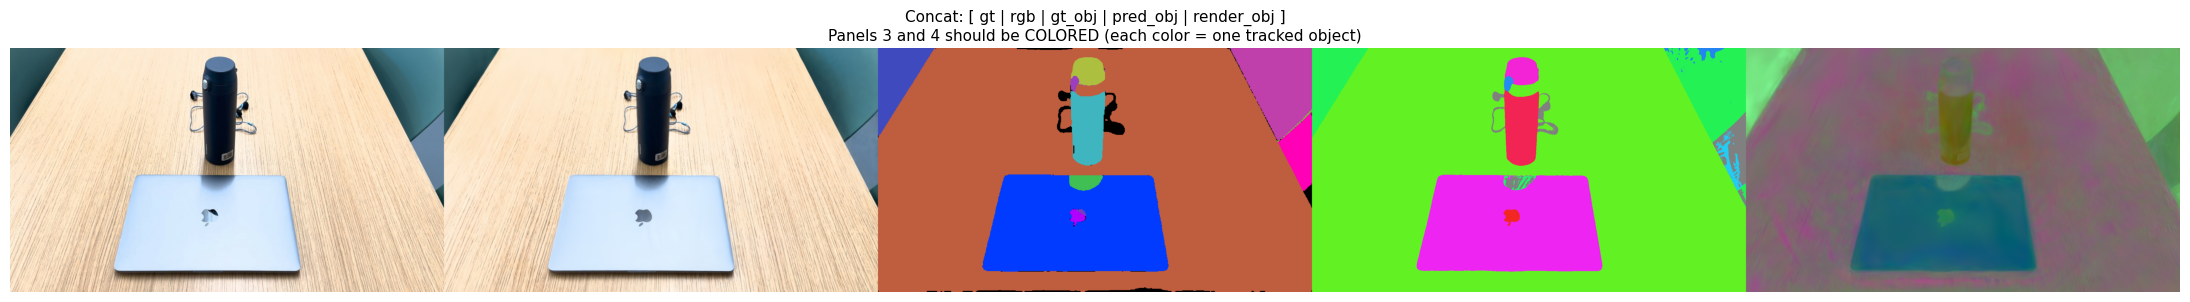

✅ 200 concat strips at: /content/scenes/my_scene/output/train/ours_5000/concat


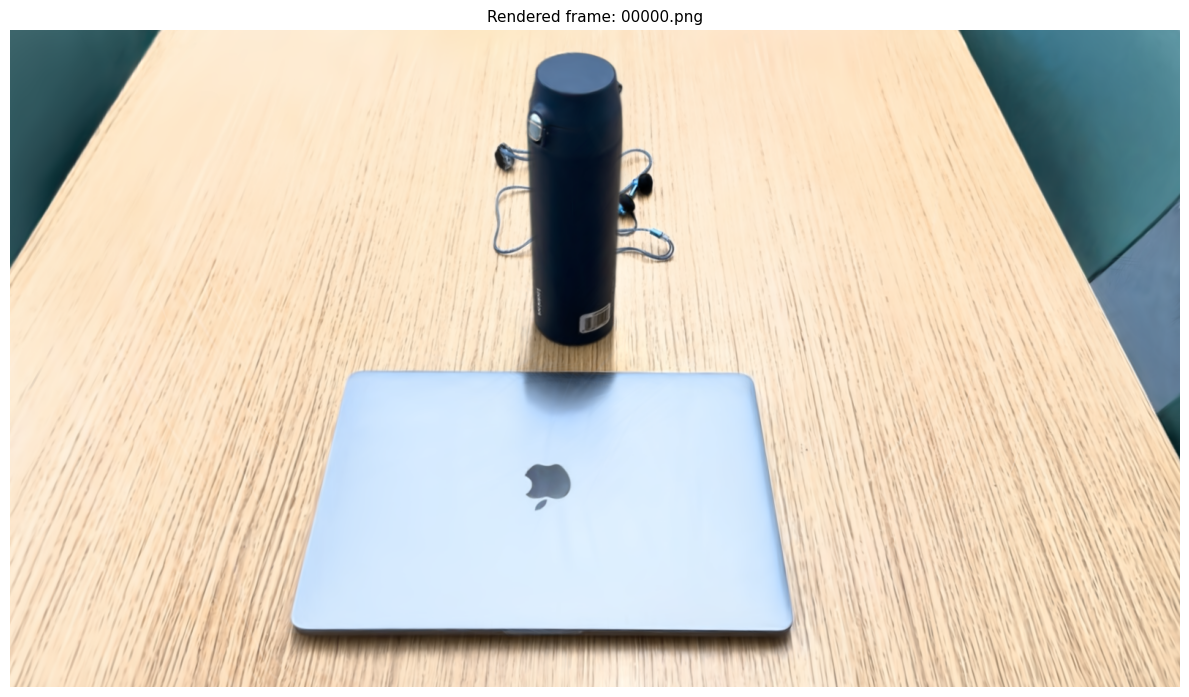

✅ 200 rendered frames at: /content/scenes/my_scene/output/train/ours_5000/renders


In [38]:
import os, glob as glob_mod
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

ITER = 5000
out  = os.path.join(OUTPUT_DIR, 'train', f'ours_{ITER}')

# ── Show one full concat strip ──────────────────────────────────────────
concat_dir = os.path.join(out, 'concat')
concat_imgs = sorted(glob_mod.glob(os.path.join(concat_dir, '*.png')))

if concat_imgs:
    fig, ax = plt.subplots(figsize=(22, 4))
    ax.imshow(mpimg.imread(concat_imgs[0]))
    ax.set_title(
        'Concat: [ gt | rgb | gt_obj | pred_obj | render_obj ]\n'
        'Panels 3 and 4 should be COLORED (each color = one tracked object)',
        fontsize=11
    )
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'✅ {len(concat_imgs)} concat strips at: {concat_dir}')
else:
    print(f'❌ No concat strips found at {concat_dir}')

# ── Show one clean rendered frame ───────────────────────────────────────
renders_dir = os.path.join(out, 'renders')
render_imgs = sorted(glob_mod.glob(os.path.join(renders_dir, '*.png')))

if render_imgs:
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(mpimg.imread(render_imgs[0]))
    ax.set_title(f'Rendered frame: {os.path.basename(render_imgs[0])}', fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f'✅ {len(render_imgs)} rendered frames at: {renders_dir}')
else:
    print(f'❌ No rendered frames found at {renders_dir}')

In [39]:
import os, shutil

ITER = 5000

print(f'Saving iteration {ITER} renders to Drive ...')

src = os.path.join(OUTPUT_DIR,  'train', f'ours_{ITER}')
dst = os.path.join(RESULTS_DIR, 'train', f'ours_{ITER}')

if not os.path.exists(src):
    print(f'❌ Local render not found at {src}')
else:
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

    n_renders = len(os.listdir(os.path.join(dst, 'renders'))) if os.path.exists(os.path.join(dst, 'renders')) else 0
    n_concat  = len(os.listdir(os.path.join(dst, 'concat')))  if os.path.exists(os.path.join(dst, 'concat'))  else 0
    n_gt      = len(os.listdir(os.path.join(dst, 'gt')))      if os.path.exists(os.path.join(dst, 'gt'))      else 0
    print(f'  ✅ Saved to: {dst}')
    print(f'     renders/ : {n_renders} frames')
    print(f'     gt/      : {n_gt} frames')
    print(f'     concat/  : {n_concat} frames')

# ── Drive size summary ──────────────────────────────────────────────────
def size_gb(path):
    total = 0
    for r, _, files in os.walk(path):
        for f in files:
            fp = os.path.join(r, f)
            if os.path.exists(fp):
                total += os.path.getsize(fp)
    return total / 1e9

print(f'\n=== Drive folder sizes ===')
for item in sorted(os.listdir(PROJECT)):
    full = os.path.join(PROJECT, item)
    if os.path.isdir(full):
        print(f'  {size_gb(full):>5.2f} GB  {item}/')

Saving iteration 5000 renders to Drive ...
  ✅ Saved to: /content/drive/MyDrive/CS515_FinalProject/results/gg_output/train/ours_5000
     renders/ : 200 frames
     gt/      : 200 frames
     concat/  : 201 frames

=== Drive folder sizes ===
   0.72 GB  Data/
   3.54 GB  checkpoints/
   0.07 GB  gaussian-grouping/
   4.31 GB  results/
   0.58 GB  shared_data/


In [40]:
from plyfile import PlyData
import os

PLY_PATH = os.path.join(OUTPUT_DIR, 'point_cloud', 'iteration_5000', 'point_cloud.ply')
plydata = PlyData.read(PLY_PATH)
all_props = [p.name for p in plydata.elements[0].properties]
print(f'Total columns: {len(all_props)}')
print(f'\nAll properties:')
for p in all_props:
    print(f'  {p}')

# Look for any object-related columns under different names
obj_props = [p for p in all_props if any(s in p.lower() for s in ['obj', 'ident', 'feat'])]
print(f'\nObject/identity/feature columns: {obj_props}')

Total columns: 78

All properties:
  x
  y
  z
  nx
  ny
  nz
  f_dc_0
  f_dc_1
  f_dc_2
  f_rest_0
  f_rest_1
  f_rest_2
  f_rest_3
  f_rest_4
  f_rest_5
  f_rest_6
  f_rest_7
  f_rest_8
  f_rest_9
  f_rest_10
  f_rest_11
  f_rest_12
  f_rest_13
  f_rest_14
  f_rest_15
  f_rest_16
  f_rest_17
  f_rest_18
  f_rest_19
  f_rest_20
  f_rest_21
  f_rest_22
  f_rest_23
  f_rest_24
  f_rest_25
  f_rest_26
  f_rest_27
  f_rest_28
  f_rest_29
  f_rest_30
  f_rest_31
  f_rest_32
  f_rest_33
  f_rest_34
  f_rest_35
  f_rest_36
  f_rest_37
  f_rest_38
  f_rest_39
  f_rest_40
  f_rest_41
  f_rest_42
  f_rest_43
  f_rest_44
  opacity
  scale_0
  scale_1
  scale_2
  rot_0
  rot_1
  rot_2
  rot_3
  obj_dc_0
  obj_dc_1
  obj_dc_2
  obj_dc_3
  obj_dc_4
  obj_dc_5
  obj_dc_6
  obj_dc_7
  obj_dc_8
  obj_dc_9
  obj_dc_10
  obj_dc_11
  obj_dc_12
  obj_dc_13
  obj_dc_14
  obj_dc_15

Object/identity/feature columns: ['obj_dc_0', 'obj_dc_1', 'obj_dc_2', 'obj_dc_3', 'obj_dc_4', 'obj_dc_5', 'obj_dc_6', 'obj_dc_

In [41]:
import os, torch
from plyfile import PlyData

ITER     = 5000
PLY_PATH = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'point_cloud.ply')
CLF_PATH = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'classifier.pth')

print(f'Loading {PLY_PATH}')
plydata = PlyData.read(PLY_PATH)
verts   = plydata.elements[0]

# ── Load identity features and convert directly to torch (skip numpy) ───
obj_props = sorted([p.name for p in verts.properties if p.name.startswith('obj_dc_')],
                   key=lambda x: int(x.split('_')[-1]))
print(f'Identity columns: {len(obj_props)}')

# Read each column into a torch tensor directly via list
id_cols = []
for p in obj_props:
    col = verts[p]   # numpy array
    id_cols.append(torch.tensor(col.tolist(), dtype=torch.float32))
id_feats = torch.stack(id_cols, dim=1)   # (N, 16)
print(f'\nPer-Gaussian identity features:')
print(f'  shape : {tuple(id_feats.shape)}')
print(f'  min   : {id_feats.min().item():.6f}')
print(f'  max   : {id_feats.max().item():.6f}')
print(f'  mean  : {id_feats.mean().item():.6f}')
print(f'  std   : {id_feats.std().item():.6f}')
print(f'  has NaN: {torch.isnan(id_feats).any().item()}')
print(f'  fraction zero: {(id_feats == 0).float().mean().item():.4f}')

# ── Per-dimension spread (the key signal) ───────────────────────────────
per_dim_std  = id_feats.std(dim=0)
per_dim_mean = id_feats.mean(dim=0)
print(f'\n=== Per-dimension stats (16 identity dims) ===')
for i in range(16):
    print(f'  dim {i:2d}: mean={per_dim_mean[i].item():+.4f}, std={per_dim_std[i].item():.4f}')
print(f'\n  Min std across dims: {per_dim_std.min().item():.6f}')
print(f'  Max std across dims: {per_dim_std.max().item():.6f}')
if per_dim_std.max().item() < 0.01:
    print(f'  ❌ Features are nearly CONSTANT — training did not learn identities')
elif per_dim_std.max().item() < 0.1:
    print(f'  ⚠️  Features have low spread — training may be undertrained')
else:
    print(f'  ✅ Features vary meaningfully across Gaussians')

# ── Load classifier ─────────────────────────────────────────────────────
sd = torch.load(CLF_PATH, map_location='cpu')
W = sd['weight']  # (256, 16, 1, 1)
b = sd['bias']    # (256,)
print(f'\nClassifier weight: {tuple(W.shape)}, bias: {tuple(b.shape)}')

# ── Run classifier on per-Gaussian features as 1×1 conv ─────────────────
feats_4d = id_feats.T.unsqueeze(0).unsqueeze(-1)   # (1, 16, N, 1)
with torch.no_grad():
    logits = torch.nn.functional.conv2d(feats_4d, W, b)   # (1, 256, N, 1)
preds = logits.argmax(dim=1).squeeze()                     # (N,)

# Get unique counts using torch
unique_preds, counts = torch.unique(preds, return_counts=True)
sorted_pairs = sorted(
    zip(unique_preds.tolist(), counts.tolist()),
    key=lambda x: -x[1]
)
top = sorted_pairs[:15]

print(f'\nClassifier predictions on raw PLY features:')
print(f'  Total Gaussians: {preds.shape[0]}')
print(f'  Unique classes : {len(unique_preds)}')
print(f'  Top 15 classes : {top}')

# ── Verdict ─────────────────────────────────────────────────────────────
print('\n=== VERDICT ===')
if len(unique_preds) == 1:
    if per_dim_std.max().item() < 0.01:
        print('Scenario C: features never learned (training failed)')
    else:
        print('Scenario B: features have spread but classifier collapses (mismatched pair)')
elif per_dim_std.max().item() < 0.01:
    print('Weird — predictions diverse but features uniform. Classifier reading bias only?')
else:
    print('Scenario A: PLY+classifier are healthy at PLY level.')
    print('         The bug is in the rasterizer pipeline (render_object outputs zeros).')

Loading /content/scenes/my_scene/output/point_cloud/iteration_5000/point_cloud.ply
Identity columns: 16

Per-Gaussian identity features:
  shape : (567763, 16)
  min   : -14.421875
  max   : 15.426107
  mean  : 0.114127
  std   : 2.004418
  has NaN: False
  fraction zero: 0.0000

=== Per-dimension stats (16 identity dims) ===
  dim  0: mean=+1.3319, std=1.7427
  dim  1: mean=+0.4365, std=1.6184
  dim  2: mean=-1.2279, std=1.5162
  dim  3: mean=-1.3659, std=1.4668
  dim  4: mean=+1.2022, std=1.5197
  dim  5: mean=+1.1177, std=1.7903
  dim  6: mean=+1.2495, std=1.4798
  dim  7: mean=+0.7584, std=1.6063
  dim  8: mean=+1.3043, std=1.5428
  dim  9: mean=-1.2505, std=1.8299
  dim 10: mean=-1.2263, std=1.6901
  dim 11: mean=-1.4632, std=1.5645
  dim 12: mean=+1.2862, std=1.7126
  dim 13: mean=-0.3863, std=1.7380
  dim 14: mean=-1.2583, std=1.5969
  dim 15: mean=+1.3179, std=1.5367

  Min std across dims: 1.466796
  Max std across dims: 1.829860
  ✅ Features vary meaningfully across Gaussians

In [198]:
import os, json

CONFIG = os.path.join(GG_DIR, 'config', 'gaussian_dataset', 'train.json')
with open(CONFIG) as f:
    cfg = json.load(f)
print(f'Current config:\n')
for k, v in cfg.items():
    print(f'  {k}: {v}')

# These are the params that affect identity training balance
print(f'\n=== Identity-training balance params ===')
print(f'  num_classes        : {cfg.get("num_classes", "unset")}')
print(f'  reg3d_interval     : {cfg.get("reg3d_interval", "unset")}')
print(f'  reg3d_lambda_val   : {cfg.get("reg3d_lambda_val", "unset")}  ← the suspect')
print(f'  reg3d_k            : {cfg.get("reg3d_k", "unset")}')
print(f'  reg3d_max_points   : {cfg.get("reg3d_max_points", "unset")}')

Current config:

  densify_until_iter: 10000
  num_classes: 256
  reg3d_interval: 5
  reg3d_k: 5
  reg3d_lambda_val: 2
  reg3d_max_points: 200000
  reg3d_sample_size: 1000

=== Identity-training balance params ===
  num_classes        : 256
  reg3d_interval     : 5
  reg3d_lambda_val   : 2  ← the suspect
  reg3d_k            : 5
  reg3d_max_points   : 200000


## Step 10 — Object Colorization
After training, you can change the color of any segmented object by modifying the Spherical Harmonic (SH) color coefficients of the Gaussians belonging to that object's group.

**How it works:** The classifier network assigns each Gaussian an object ID. We load the trained PLY, find Gaussians assigned to the target object ID, and overwrite their SH DC component with the desired RGB color.

In [42]:
import os, shutil

ITER = 5000  # change if you trained to a different iteration

# Source on Drive
src_iter = os.path.join(PROJECT, 'results', 'gg_output', 'point_cloud', f'iteration_{ITER}')
# Destination local
dst_iter = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}')

print(f"Source (Drive): {src_iter}")
print(f"  Exists: {os.path.exists(src_iter)}")
print(f"Destination (local): {dst_iter}")

assert os.path.exists(src_iter), f"❌ Not found on Drive: {src_iter}\nCheck the diagnostic cell above for the correct path."

os.makedirs(dst_iter, exist_ok=True)

for fname in ['point_cloud.ply', 'classifier.pth']:
    src_f = os.path.join(src_iter, fname)
    dst_f = os.path.join(dst_iter, fname)
    if os.path.exists(src_f):
        shutil.copy(src_f, dst_f)
        size = os.path.getsize(dst_f) / 1e6
        print(f"✅ Copied {fname} ({size:.1f} MB)")
    else:
        print(f"❌ Missing on Drive: {src_f}")

Source (Drive): /content/drive/MyDrive/CS515_FinalProject/results/gg_output/point_cloud/iteration_5000
  Exists: True
Destination (local): /content/scenes/my_scene/output/point_cloud/iteration_5000
✅ Copied point_cloud.ply (177.1 MB)
✅ Copied classifier.pth (0.0 MB)


In [22]:
import os, shutil

gg_drive = os.path.join(PROJECT, 'results', 'gg_output')

for fname in ['cfg_args', 'cameras.json']:
    src = os.path.join(gg_drive, fname)
    dst = os.path.join(OUTPUT_DIR, fname)
    if not os.path.exists(dst) and os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ Copied {fname}")
    elif os.path.exists(dst):
        print(f"✅ Already exists: {fname}")
    else:
        print(f"❌ Missing on Drive: {fname}")

print("\nAll set — now re-run Cell 55 (Step 11).")

✅ Already exists: cfg_args
✅ Already exists: cameras.json

All set — now re-run Cell 55 (Step 11).


In [23]:
import os, shutil

colmap_drive = os.path.join(PROJECT, 'shared_data', 'colmap')

if os.path.exists(UNDIST_DIR):
    shutil.rmtree(UNDIST_DIR)

print("📥 Copying COLMAP/undistorted data from Drive ... (this may take a minute)")
shutil.copytree(colmap_drive, UNDIST_DIR)
print(f"✅ Done: {UNDIST_DIR}")

# Verify
for sub in ['images', 'sparse']:
    p = os.path.join(UNDIST_DIR, sub)
    print(f"  {sub}/: {'✅' if os.path.exists(p) else '❌ still missing'}")

📥 Copying COLMAP/undistorted data from Drive ... (this may take a minute)
✅ Done: /content/scenes/my_scene/undistorted
  images/: ✅
  sparse/: ✅


📸 Snapshotted original renders → /content/scenes/my_scene/output/edited_original/renders


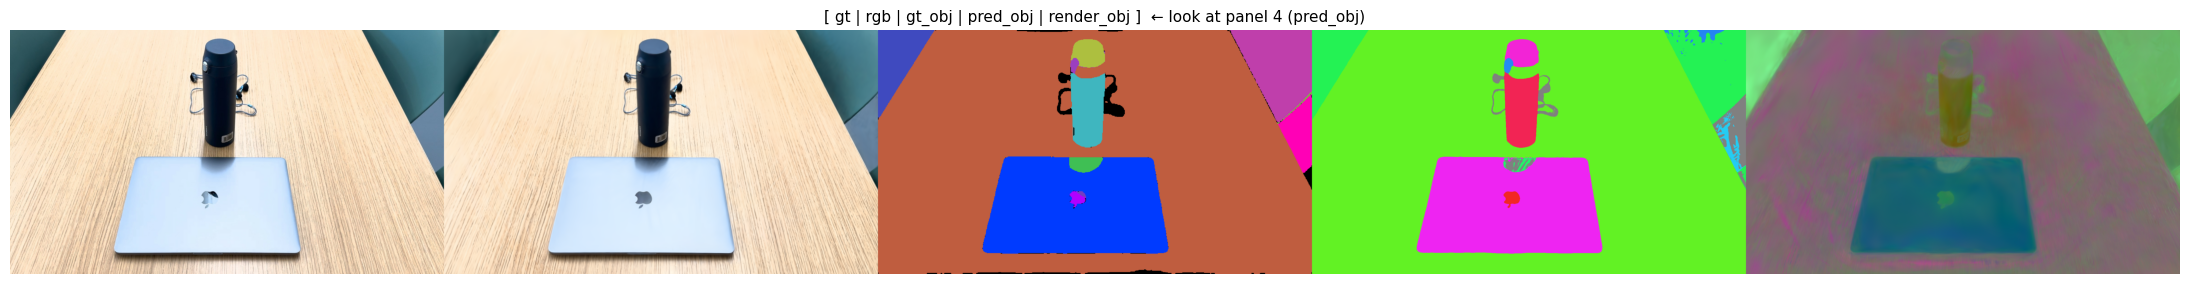


Loading PLY and classifier ...
  Found 16 identity columns (e.g. obj_dc_0 ... obj_dc_15)
  Identity feature matrix: (567763, 16), dtype=torch.float32

  ID    Gaussians   % of scene
  ----  ----------  ----------
   102      457212       80.5%
     0       39499        7.0%
    14       22931        4.0%
   179       11228        2.0%
   106        8926        1.6%
   188        5640        1.0%
   151        4234        0.7%
    99        3012        0.5%
   202        2804        0.5%
   210        2775        0.5%
    92        2269        0.4%
   121        2149        0.4%
    87        1708        0.3%
   130        1193        0.2%
   116        1015        0.2%

The largest ID is usually the background/table.
Smaller IDs (a few %) are individual objects (water bottle, laptop, earphones).
Pick a candidate ID and run Cell 10.3 to confirm it's the right object visually.


In [43]:
import os, glob as glob_mod, shutil, numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import torch
from plyfile import PlyData

ITER         = 5000           # working at 5k checkpoint
NUM_CLASSES  = 256
PLY_PATH = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'point_cloud.ply')
CLF_PATH = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'classifier.pth')

assert os.path.exists(PLY_PATH), f'Missing PLY: {PLY_PATH}'
assert os.path.exists(CLF_PATH), f'Missing classifier: {CLF_PATH}'

# ── 0. Snapshot the ORIGINAL render so Step 12 has a clean "before" ─────
orig_render_src = os.path.join(OUTPUT_DIR, 'train', f'ours_{ITER}', 'renders')
orig_render_dst = os.path.join(OUTPUT_DIR, 'edited_original', 'renders')
if os.path.exists(orig_render_src) and not os.path.exists(orig_render_dst):
    os.makedirs(os.path.dirname(orig_render_dst), exist_ok=True)
    shutil.copytree(orig_render_src, orig_render_dst)
    print(f'📸 Snapshotted original renders → {orig_render_dst}')
elif os.path.exists(orig_render_dst):
    print(f'📸 Original render snapshot already exists at {orig_render_dst}')
else:
    print(f'⚠️  No original renders found at {orig_render_src} — '
          f'rerun Step 9 for iter {ITER} if you want a "before" image.')

# ── 1. Show the concat strip so you can SEE the colored objects ─────────
concat_dir = os.path.join(OUTPUT_DIR, 'train', f'ours_{ITER}', 'concat')
concat_imgs = sorted(glob_mod.glob(os.path.join(concat_dir, '*.png')))

if concat_imgs:
    fig, ax = plt.subplots(figsize=(22, 4))
    ax.imshow(mpimg.imread(concat_imgs[0]))
    ax.set_title('[ gt | rgb | gt_obj | pred_obj | render_obj ]  ← look at panel 4 (pred_obj)',
                 fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f'(no concat images found at {concat_dir})')

# ── 2. List the object IDs the classifier predicts for the Gaussians ────
print('\nLoading PLY and classifier ...')
plydata  = PlyData.read(PLY_PATH)
verts    = plydata.elements[0]

# Gaussian Grouping stores per-Gaussian identity features as obj_dc_0 ... obj_dc_15
id_props = sorted(
    [p.name for p in verts.properties if p.name.startswith('obj_dc_')],
    key=lambda x: int(x.split('_')[-1]),
)
if not id_props:
    id_props = sorted([p.name for p in verts.properties if 'identity' in p.name.lower()])
assert id_props, (
    f'No object-identity columns found in {PLY_PATH}. '
    f'Available properties: {[p.name for p in verts.properties][:20]} ...'
)
print(f'  Found {len(id_props)} identity columns (e.g. {id_props[0]} ... {id_props[-1]})')

# ── Build features as torch directly via Python lists ───────────────────
# torch.from_numpy is broken on this PyTorch/NumPy build (raises a confusing
# "expected np.ndarray (got numpy.ndarray)"). Going through .tolist() into
# torch.tensor sidesteps the buffer-protocol path. This is the exact same
# pattern Cell 44 used successfully.
id_cols = []
for p in id_props:
    col = verts[p]                                  # numpy column
    id_cols.append(torch.tensor(col.tolist(), dtype=torch.float32))
id_feats_t = torch.stack(id_cols, dim=1)            # (N, 16) torch tensor on CPU
print(f'  Identity feature matrix: {tuple(id_feats_t.shape)}, dtype={id_feats_t.dtype}')

# ── Load classifier ─────────────────────────────────────────────────────
classifier = torch.nn.Linear(id_feats_t.shape[1], NUM_CLASSES).cuda()
state = torch.load(CLF_PATH, map_location='cuda')

# Classifier is saved as a 1x1 conv: weight (256, 16, 1, 1), bias (256,).
# Linear expects weight (256, 16). Squeeze the trailing 1x1 so it loads cleanly.
if state['weight'].dim() == 4:
    state = {'weight': state['weight'].squeeze(-1).squeeze(-1),
             'bias':   state['bias']}
classifier.load_state_dict(state)
classifier.eval()

with torch.no_grad():
    feats    = id_feats_t.cuda()
    pred_ids = classifier(feats).argmax(dim=1).cpu().numpy()

unique_ids, counts = np.unique(pred_ids, return_counts=True)
top_ids = sorted(zip(unique_ids, counts), key=lambda x: -x[1])

print(f'\n  ID    Gaussians   % of scene')
print(f'  ----  ----------  ----------')
for uid, cnt in top_ids[:15]:
    print(f'  {uid:>4}  {cnt:>10}  {cnt/len(pred_ids)*100:>9.1f}%')

print('\nThe largest ID is usually the background/table.')
print('Smaller IDs (a few %) are individual objects (water bottle, laptop, earphones).')
print('Pick a candidate ID and run Cell 10.3 to confirm it\'s the right object visually.')

ID 179: 11228 Gaussians (1.98% of scene)
  centroid (x, y, z): (-0.906, +2.336, +3.274)
  extent   (x, y, z): (8.123, 5.307, 5.443)


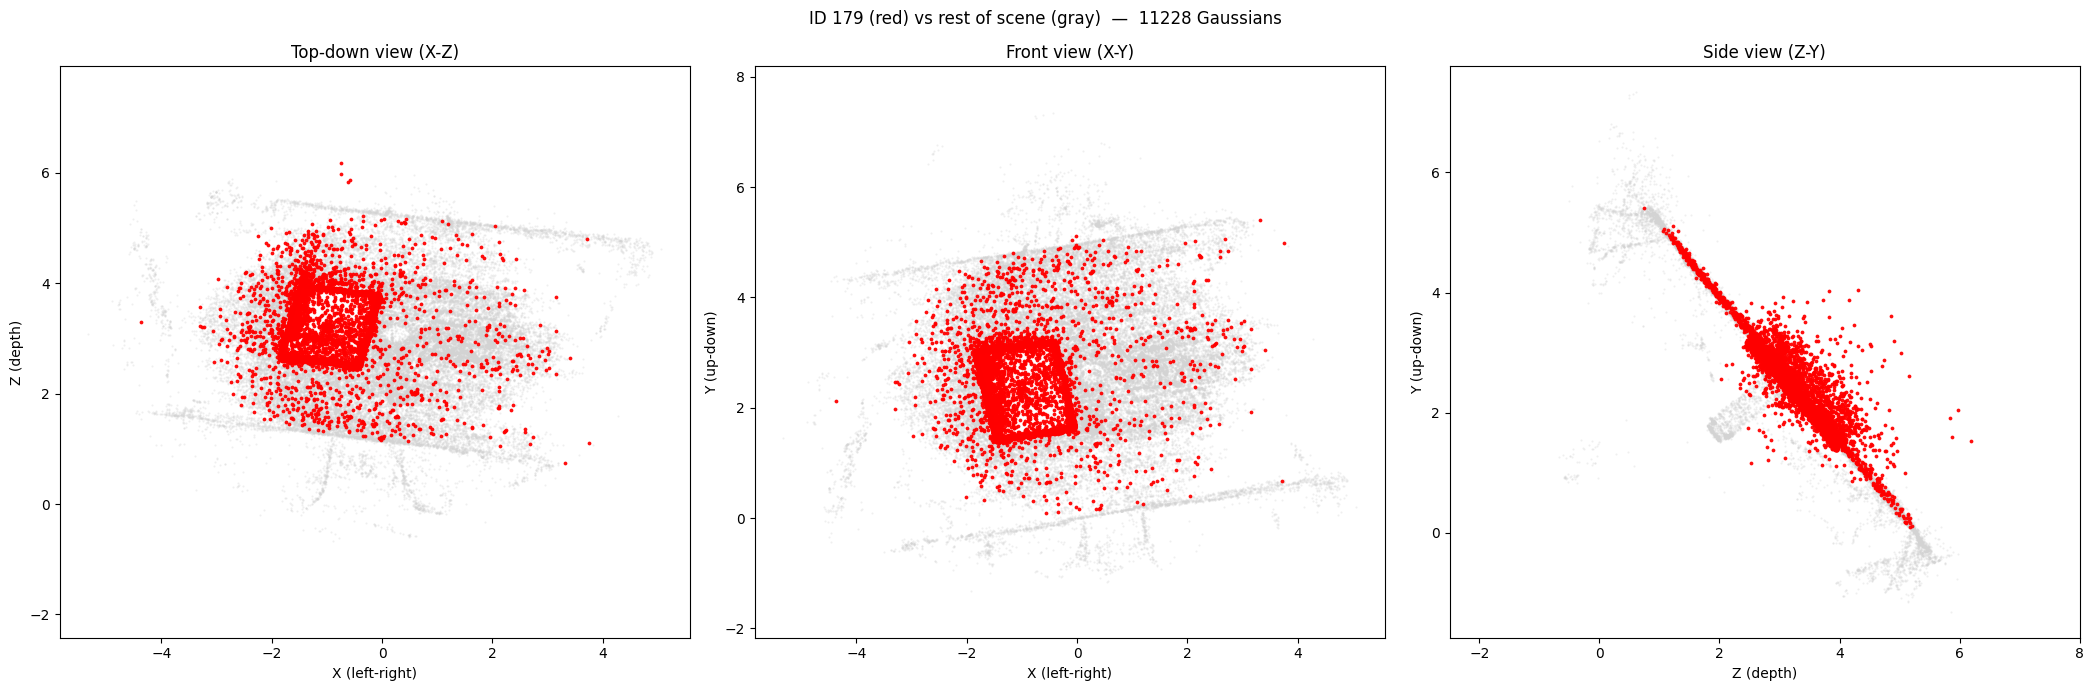


Look at all three views:
  - Top-down (X-Z): does the red blob sit on the table where the laptop should be?
  - Front (X-Y):    does it have laptop-like proportions (wide, not tall)?
  - Side (Z-Y):     does it have a thin profile?

If YES, set TARGET_OBJ_ID=179 in the colorize cell (10.4).
If NO,  change CANDIDATE_ID at the top of THIS cell and re-run.


In [45]:
import os, numpy as np, torch
import matplotlib.pyplot as plt
from plyfile import PlyData

# ── Pick the candidate ID to visualize ──────────────────────────────────
CANDIDATE_ID = 179   # ← try ID 0 first (your laptop guess). Other interesting
                   #    candidates from the table: 14, 179, 106, 188, 151
ITER         = 5000        # match the iteration used in Cell 10.2
NUM_CLASSES  = 256
# ────────────────────────────────────────────────────────────────────────

PLY_PATH = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'point_cloud.ply')
CLF_PATH = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'classifier.pth')

assert os.path.exists(PLY_PATH), f'Missing PLY: {PLY_PATH}'
assert os.path.exists(CLF_PATH), f'Missing classifier: {CLF_PATH}'

plydata = PlyData.read(PLY_PATH)
verts   = plydata.elements[0]

# XYZ positions — go through .tolist() to dodge the torch.from_numpy bug,
# then convert back to numpy from python lists (same pattern as Cell 10.2).
xyz = np.array(
    [verts['x'].tolist(), verts['y'].tolist(), verts['z'].tolist()],
    dtype=np.float32,
).T   # (N, 3)

# Identity features: obj_dc_0 ... obj_dc_15 (NOT 'identity_*')
id_props = sorted(
    [p.name for p in verts.properties if p.name.startswith('obj_dc_')],
    key=lambda x: int(x.split('_')[-1]),
)
if not id_props:
    id_props = sorted([p.name for p in verts.properties if 'identity' in p.name.lower()])
assert id_props, f'No object-identity columns in {PLY_PATH}'

id_cols    = [torch.tensor(verts[p].tolist(), dtype=torch.float32) for p in id_props]
id_feats_t = torch.stack(id_cols, dim=1)          # (N, 16)

# Classifier
classifier = torch.nn.Linear(id_feats_t.shape[1], NUM_CLASSES).cuda()
state = torch.load(CLF_PATH, map_location='cuda')
if state['weight'].dim() == 4:
    state = {'weight': state['weight'].squeeze(-1).squeeze(-1),
             'bias':   state['bias']}
classifier.load_state_dict(state)
classifier.eval()

with torch.no_grad():
    pred_ids = classifier(id_feats_t.cuda()).argmax(dim=1).cpu().numpy()

mask = (pred_ids == CANDIDATE_ID)
print(f'ID {CANDIDATE_ID}: {mask.sum()} Gaussians ({mask.sum()/len(pred_ids)*100:.2f}% of scene)')

if mask.sum() == 0:
    print('❌ No Gaussians for that ID — pick a different one from the table in Cell 10.2.')
else:
    # Centroid + extent. Compute via torch — numpy's .min/.max/.ptp are hitting
    # the same ABI-mismatch bug as torch.from_numpy in this kernel.
    obj_xyz_t = torch.tensor(xyz[mask].tolist(), dtype=torch.float32)
    cx, cy, cz = obj_xyz_t.mean(dim=0).tolist()
    mn         = obj_xyz_t.min(dim=0).values.tolist()
    mx         = obj_xyz_t.max(dim=0).values.tolist()
    ex, ey, ez = mx[0] - mn[0], mx[1] - mn[1], mx[2] - mn[2]
    print(f'  centroid (x, y, z): ({cx:+.3f}, {cy:+.3f}, {cz:+.3f})')
    print(f'  extent   (x, y, z): ({ex:.3f}, {ey:.3f}, {ez:.3f})')

    # Three orthogonal projections — easier to identify the object than two
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    views = [
        (0, 2, 'X (left-right)', 'Z (depth)',     'Top-down view (X-Z)'),
        (0, 1, 'X (left-right)', 'Y (up-down)',   'Front view (X-Y)'),
        (2, 1, 'Z (depth)',      'Y (up-down)',   'Side view (Z-Y)'),
    ]
    # Subsample background for speed (567k points is slow to scatter)
    rng    = np.random.default_rng(0)
    bg_pos = np.where(~mask)[0]
    bg_idx = rng.choice(bg_pos, size=min(50_000, len(bg_pos)), replace=False)

    for ax, (xi, yi, xl, yl, title) in zip(axes, views):
        ax.scatter(xyz[bg_idx, xi], xyz[bg_idx, yi], c='lightgray', s=0.3, alpha=0.3)
        ax.scatter(xyz[mask,   xi], xyz[mask,   yi], c='red',       s=3,   alpha=0.9)
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        ax.set_title(title)
        ax.set_aspect('equal', adjustable='datalim')
    fig.suptitle(f'ID {CANDIDATE_ID} (red) vs rest of scene (gray)  —  '
                 f'{mask.sum()} Gaussians', fontsize=12)
    plt.tight_layout()
    plt.show()

    print('\nLook at all three views:')
    print('  - Top-down (X-Z): does the red blob sit on the table where the laptop should be?')
    print('  - Front (X-Y):    does it have laptop-like proportions (wide, not tall)?')
    print('  - Side (Z-Y):     does it have a thin profile?')
    print(f'\nIf YES, set TARGET_OBJ_ID={CANDIDATE_ID} in the colorize cell (10.4).')
    print( 'If NO,  change CANDIDATE_ID at the top of THIS cell and re-run.')

In [52]:
import os, sys, glob as glob_mod, subprocess

# ── EDIT THESE ──────────────────────────────────────────────────────────
TARGET_OBJ_ID = 179                # laptop, confirmed in Cell 10.3
NEW_COLOR_RGB = (255, 0, 0)      # bright red — change if you want another color
ITER_TO_EDIT  = 5000             # match the iter you picked IDs from
# ────────────────────────────────────────────────────────────────────────

# Make GG and any installed eggs importable from the subprocess
for egg in glob_mod.glob('/usr/local/lib/python3.12/dist-packages/*.egg'):
    if egg not in sys.path:
        sys.path.insert(0, egg)

colorize_script = f'''
import sys, os, traceback
try:
    import torch, numpy as np
    sys.path.insert(0, "{GG_DIR}")
    from scene.gaussian_model import GaussianModel

    OUTPUT_DIR  = "{OUTPUT_DIR}"
    ITER        = {ITER_TO_EDIT}
    TARGET_ID   = {TARGET_OBJ_ID}
    NEW_COLOR   = {NEW_COLOR_RGB}
    NUM_CLASSES = 256

    PLY_PATH = os.path.join(OUTPUT_DIR, "point_cloud", f"iteration_{{ITER}}", "point_cloud.ply")
    CLF_PATH = os.path.join(OUTPUT_DIR, "point_cloud", f"iteration_{{ITER}}", "classifier.pth")
    OUT_DIR  = os.path.join(OUTPUT_DIR, "edited_colorize")
    os.makedirs(OUT_DIR, exist_ok=True)

    assert os.path.exists(PLY_PATH), f"Missing PLY: {{PLY_PATH}}"
    assert os.path.exists(CLF_PATH), f"Missing classifier: {{CLF_PATH}}"

    print(f"[colorize] Loading Gaussians from {{PLY_PATH}}", flush=True)
    gaussians = GaussianModel(3)
    gaussians.load_ply(PLY_PATH)
    print(f"[colorize] Loaded GaussianModel", flush=True)

    classifier = torch.nn.Linear(16, NUM_CLASSES).cuda()
    state = torch.load(CLF_PATH, map_location="cuda")
    if state["weight"].dim() == 4:
        state = {{"weight": state["weight"].squeeze(-1).squeeze(-1),
                  "bias":   state["bias"]}}
    classifier.load_state_dict(state)
    classifier.eval()
    print(f"[colorize] Loaded classifier", flush=True)

    # get_identity_encoding doesn't exist in this GG build.
    # Read obj_dc_* directly from the PLY file instead — same approach as Cell 10.2.
    from plyfile import PlyData
    plydata  = PlyData.read(PLY_PATH)
    verts    = plydata.elements[0]
    id_props = sorted([p.name for p in verts.properties if p.name.startswith('obj_dc_')],
                      key=lambda x: int(x.split('_')[-1]))
    print(f"[colorize] Found {{len(id_props)}} identity columns", flush=True)
    id_cols    = [torch.tensor(verts[p].tolist(), dtype=torch.float32) for p in id_props]
    id_feats_t = torch.stack(id_cols, dim=1).cuda()
    print(f"[colorize] id_enc shape: {{tuple(id_feats_t.shape)}}", flush=True)
    with torch.no_grad():
        pred_ids = classifier(id_feats_t).argmax(dim=1).cpu().numpy()

    mask     = (pred_ids == TARGET_ID)
    n_total  = pred_ids.shape[0]
    n_target = int(mask.sum())
    print(f"[colorize] Target ID {{TARGET_ID}}: {{n_target}} / {{n_total}} "
          f"({{100*n_target/n_total:.2f}}%)", flush=True)

    if n_target == 0:
        print("[colorize] ERROR: no Gaussians match that ID.", flush=True)
        sys.exit(1)

    C0 = 0.28209479177387814
    rgb_01 = np.array(NEW_COLOR) / 255.0
    sh_dc  = (rgb_01 - 0.5) / C0
    print(f"[colorize] sh_dc = {{sh_dc}}", flush=True)

    # Build the boolean mask on CUDA without touching torch.from_numpy
    mask_t  = torch.tensor(mask.tolist(), dtype=torch.bool).cuda()
    sh_dc_t = torch.tensor(sh_dc.tolist(), dtype=torch.float32).cuda()

    print(f"[colorize] _features_dc shape:   {{tuple(gaussians._features_dc.shape)}}", flush=True)
    print(f"[colorize] _features_rest shape: {{tuple(gaussians._features_rest.shape)}}", flush=True)

    gaussians._features_dc.data[mask_t, 0, :]    = sh_dc_t
    gaussians._features_rest.data[mask_t, :, :]  = 0.0
    print(f"[colorize] Recolored {{n_target}} Gaussians", flush=True)

    out_ply = os.path.join(OUT_DIR, "point_cloud_colorized.ply")
    gaussians.save_ply(out_ply)
    size_mb = os.path.getsize(out_ply) / 1e6
    print(f"[colorize] Saved: {{out_ply}} ({{size_mb:.1f}} MB)", flush=True)

except Exception as e:
    print("[colorize] EXCEPTION:", file=sys.stderr, flush=True)
    traceback.print_exc()
    sys.exit(2)
'''

with open('/content/run_colorize.py', 'w') as f:
    f.write(colorize_script)

print(f'🎨 Colorizing object ID {TARGET_OBJ_ID} → RGB {NEW_COLOR_RGB} '
      f'at iteration {ITER_TO_EDIT} ...\n')

result = subprocess.run(
    ['python', '-u', '/content/run_colorize.py'],
    capture_output=True, text=True,
)

# Always print whatever the subprocess emitted, success or failure.
if result.stdout:
    print('--- subprocess stdout ---')
    print(result.stdout)
if result.stderr:
    print('--- subprocess stderr ---')
    print(result.stderr)

if result.returncode == 0:
    print('\n✅ Colorized PLY ready — run Cell 10.5 to render it')
else:
    print(f'\n❌ Colorize failed (exit code {result.returncode})')

🎨 Colorizing object ID 179 → RGB (255, 0, 0) at iteration 5000 ...

--- subprocess stdout ---
[colorize] Loading Gaussians from /content/scenes/my_scene/output/point_cloud/iteration_5000/point_cloud.ply
[colorize] Loaded GaussianModel
[colorize] Loaded classifier
[colorize] Found 16 identity columns
[colorize] id_enc shape: (567763, 16)
[colorize] Target ID 179: 11228 / 567763 (1.98%)
[colorize] sh_dc = [ 1.77245385 -1.77245385 -1.77245385]
[colorize] _features_dc shape:   (567763, 1, 3)
[colorize] _features_rest shape: (567763, 15, 3)
[colorize] Recolored 11228 Gaussians
[colorize] Saved: /content/scenes/my_scene/output/edited_colorize/point_cloud_colorized.ply (177.1 MB)


✅ Colorized PLY ready — run Cell 10.5 to render it


In [53]:
import os, shutil, subprocess

ITER         = 5000    # match your working iteration
ORIG_PLY     = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'point_cloud.ply')
EDITED_PLY   = os.path.join(OUTPUT_DIR, 'edited_colorize', 'point_cloud_colorized.ply')
BACKUP_PLY   = ORIG_PLY + '.backup'
COLOR_RENDER_DST = os.path.join(OUTPUT_DIR, 'edited_colorize', 'renders')

assert os.path.exists(ORIG_PLY),   f'Missing original PLY: {ORIG_PLY}'
assert os.path.exists(EDITED_PLY), f'Missing colorized PLY: {EDITED_PLY} — run Cell 10.4 first'

# Backup original once (never overwrite an existing backup)
if not os.path.exists(BACKUP_PLY):
    shutil.copy(ORIG_PLY, BACKUP_PLY)
    print('  ✅ Original PLY backed up')
else:
    print('  ✅ Backup already exists — skipping')

# Swap in the colorized PLY so render.py picks it up
shutil.copy(EDITED_PLY, ORIG_PLY)
print('  🔄 Swapped in colorized PLY')

# Wipe prior render output so render.py doesn't skip frames it thinks are done
old_render = os.path.join(OUTPUT_DIR, 'train', f'ours_{ITER}')
if os.path.exists(old_render):
    shutil.rmtree(old_render)

print('🚀 Rendering colorized scene ...\n')
try:
    proc = subprocess.Popen(
        ['python', '-u', 'render.py',
         '-m', OUTPUT_DIR, '-s', UNDIST_DIR,
         '--iteration', str(ITER), '--skip_test', '--num_classes', '256'],
        cwd=GG_DIR,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()

    if proc.returncode != 0:
        print(f'\n❌ Render failed (code {proc.returncode})')
    else:
        # Move renders to a labeled folder so they don't get clobbered by later renders
        src = os.path.join(old_render, 'renders')
        if os.path.exists(COLOR_RENDER_DST):
            shutil.rmtree(COLOR_RENDER_DST)
        shutil.copytree(src, COLOR_RENDER_DST)
        n = len(os.listdir(COLOR_RENDER_DST))
        print(f'\n✅ Colorized renders saved locally: {COLOR_RENDER_DST} ({n} frames)')
        print(f'   (Drive backup happens in Step 12)')
finally:
    # ALWAYS restore the original PLY — even if render crashed
    shutil.copy(BACKUP_PLY, ORIG_PLY)
    print('  ✅ Original PLY restored')

  ✅ Backup already exists — skipping
  🔄 Swapped in colorized PLY
🚀 Rendering colorized scene ...

Looking for config file in /content/scenes/my_scene/output/cfg_args
Config file found: /content/scenes/my_scene/output/cfg_args
Rendering /content/scenes/my_scene/output
Loading trained model at iteration 5000 [28/04 04:37:18]

Reading camera 1/200
Reading camera 2/200
Reading camera 3/200
Reading camera 4/200
Reading camera 5/200
Reading camera 6/200
Reading camera 7/200
Reading camera 8/200
Reading camera 9/200
Reading camera 10/200
Reading camera 11/200
Reading camera 12/200
Reading camera 13/200
Reading camera 14/200
Reading camera 15/200
Reading camera 16/200
Reading camera 17/200
Reading camera 18/200
Reading camera 19/200
Reading camera 20/200
Reading camera 21/200
Reading camera 22/200
Reading camera 23/200
Reading camera 24/200
Reading camera 25/200
Reading camera 26/200
Reading camera 27/200
Reading camera 28/200
Reading camera 29/200
Reading camera 30/200
Reading camera 31/200


In [237]:
import os, shutil

src = os.path.join(OUTPUT_DIR, 'edited_colorize')
dst = os.path.join(RESULTS_DIR, 'edited_colorize')

assert os.path.exists(src), f'Missing: {src} — run Cell 10.5 first'

if os.path.exists(dst):
    shutil.rmtree(dst)
shutil.copytree(src, dst)

n_renders = len(os.listdir(os.path.join(dst, 'renders'))) if os.path.exists(os.path.join(dst, 'renders')) else 0
size_mb   = sum(os.path.getsize(os.path.join(r, f))
                for r, _, fs in os.walk(dst) for f in fs) / 1e6

print(f'✅ Saved edited_colorize → {dst}')
print(f'   {n_renders} render frames, {size_mb:.1f} MB total')

✅ Saved edited_colorize → /content/drive/MyDrive/CS515_FinalProject/results/gg_output/edited_colorize
   200 render frames, 449.3 MB total


## Step 11 — Object Removal
Remove an object by deleting all Gaussians assigned to its ID. The background behind it may have a hole if the camera never saw behind the object — that is expected and matches the paper's results.

In [46]:
import os, sys, glob as glob_mod, subprocess

# ── EDIT THESE ──────────────────────────────────────────────────────────
REMOVE_OBJ_ID = 179            # water bottle, confirmed in Cell 10.3
ITER_TO_EDIT  = 5000             # match the iter you picked IDs from
# ────────────────────────────────────────────────────────────────────────

for egg in glob_mod.glob('/usr/local/lib/python3.12/dist-packages/*.egg'):
    if egg not in sys.path:
        sys.path.insert(0, egg)

removal_script = f'''
import sys, os, traceback
try:
    import torch, numpy as np
    from plyfile import PlyData, PlyElement
    sys.path.insert(0, "{GG_DIR}")
    from scene.gaussian_model import GaussianModel

    OUTPUT_DIR  = "{OUTPUT_DIR}"
    ITER        = {ITER_TO_EDIT}
    TARGET_ID   = {REMOVE_OBJ_ID}
    NUM_CLASSES = 256

    PLY_PATH = os.path.join(OUTPUT_DIR, "point_cloud", f"iteration_{{ITER}}", "point_cloud.ply")
    CLF_PATH = os.path.join(OUTPUT_DIR, "point_cloud", f"iteration_{{ITER}}", "classifier.pth")
    OUT_DIR  = os.path.join(OUTPUT_DIR, "edited_removal")
    os.makedirs(OUT_DIR, exist_ok=True)

    assert os.path.exists(PLY_PATH), f"Missing PLY: {{PLY_PATH}}"
    assert os.path.exists(CLF_PATH), f"Missing classifier: {{CLF_PATH}}"

    # ── Load classifier (same pattern as colorize cell) ──────────────────
    print("[removal] Loading classifier ...", flush=True)
    classifier = torch.nn.Linear(16, NUM_CLASSES).cuda()
    state = torch.load(CLF_PATH, map_location="cuda")
    if state["weight"].dim() == 4:
        state = {{"weight": state["weight"].squeeze(-1).squeeze(-1),
                  "bias":   state["bias"]}}
    classifier.load_state_dict(state)
    classifier.eval()

    # ── Read identity features directly from PLY (no GaussianModel needed) ─
    print(f"[removal] Reading PLY from {{PLY_PATH}} ...", flush=True)
    plydata  = PlyData.read(PLY_PATH)
    verts    = plydata.elements[0]
    id_props = sorted([p.name for p in verts.properties if p.name.startswith("obj_dc_")],
                      key=lambda x: int(x.split("_")[-1]))
    print(f"[removal] Found {{len(id_props)}} identity columns", flush=True)

    id_cols    = [torch.tensor(verts[p].tolist(), dtype=torch.float32) for p in id_props]
    id_feats_t = torch.stack(id_cols, dim=1).cuda()

    with torch.no_grad():
        pred_ids = classifier(id_feats_t).argmax(dim=1).cpu().numpy()

    remove_mask = (pred_ids == TARGET_ID)
    keep_mask   = ~remove_mask
    n_total     = len(pred_ids)
    n_remove    = int(remove_mask.sum())
    n_keep      = int(keep_mask.sum())
    print(f"[removal] Target ID {{TARGET_ID}}: removing {{n_remove}} / {{n_total}} "
          f"({{100*n_remove/n_total:.2f}}%), keeping {{n_keep}}", flush=True)

    if n_remove == 0:
        print("[removal] ERROR: no Gaussians match that ID.", flush=True)
        sys.exit(1)

    # ── Filter every PLY property column directly ─────────────────────────
    # This completely bypasses prune_points() and the optimizer dependency.
    # We just keep the rows where keep_mask is True.
    import numpy as np
    all_props  = [p.name for p in verts.properties]
    kept_data  = {{}}
    for prop in all_props:
        col = np.array(verts[prop].tolist(), dtype=np.float32)
        kept_data[prop] = col[keep_mask]

    # Reconstruct a PlyElement with the filtered data
    structured = np.zeros(n_keep, dtype=[(p, "f4") for p in all_props])
    for prop in all_props:
        structured[prop] = kept_data[prop]

    el      = PlyElement.describe(structured, "vertex")
    out_ply = os.path.join(OUT_DIR, "point_cloud_removed.ply")
    PlyData([el]).write(out_ply)

    size_mb = os.path.getsize(out_ply) / 1e6
    print(f"[removal] Saved: {{out_ply}} ({{size_mb:.1f}} MB)", flush=True)
    print(f"[removal] Removed {{n_remove}} Gaussians, kept {{n_keep}}", flush=True)

except Exception as e:
    print("[removal] EXCEPTION:", file=sys.stderr, flush=True)
    traceback.print_exc()
    sys.exit(2)
'''

with open('/content/run_removal.py', 'w') as f:
    f.write(removal_script)

print(f'🗑️  Removing object ID {REMOVE_OBJ_ID} at iteration {ITER_TO_EDIT} ...\n')

result = subprocess.run(
    ['python', '-u', '/content/run_removal.py'],
    capture_output=True, text=True,
)

if result.stdout:
    print('--- subprocess stdout ---')
    print(result.stdout)
if result.stderr:
    print('--- subprocess stderr ---')
    print(result.stderr)

if result.returncode == 0:
    print('\n✅ Removal PLY ready — run the render cell next')
else:
    print(f'\n❌ Removal failed (exit code {result.returncode})')

🗑️  Removing object ID 179 at iteration 5000 ...

--- subprocess stdout ---
[removal] Loading classifier ...
[removal] Reading PLY from /content/scenes/my_scene/output/point_cloud/iteration_5000/point_cloud.ply ...
[removal] Found 16 identity columns
[removal] Target ID 179: removing 11228 / 567763 (1.98%), keeping 556535
[removal] Saved: /content/scenes/my_scene/output/edited_removal/point_cloud_removed.ply (173.6 MB)
[removal] Removed 11228 Gaussians, kept 556535


✅ Removal PLY ready — run the render cell next


In [47]:
import os, shutil, subprocess

ITER             = 5000
ORIG_PLY         = os.path.join(OUTPUT_DIR, 'point_cloud', f'iteration_{ITER}', 'point_cloud.ply')
REMOVED_PLY      = os.path.join(OUTPUT_DIR, 'edited_removal', 'point_cloud_removed.ply')
BACKUP_PLY       = ORIG_PLY + '.backup'
REMOVAL_RENDER_DST = os.path.join(OUTPUT_DIR, 'edited_removal', 'renders')

assert os.path.exists(ORIG_PLY),    f'Missing original PLY: {ORIG_PLY}'
assert os.path.exists(REMOVED_PLY), f'Missing removed PLY: {REMOVED_PLY} — run Cell 11.1 first'

# Backup original once (never overwrite an existing backup)
if not os.path.exists(BACKUP_PLY):
    shutil.copy(ORIG_PLY, BACKUP_PLY)
    print('  ✅ Original PLY backed up')
else:
    print('  ✅ Backup already exists — skipping')

# Swap in the removed PLY
shutil.copy(REMOVED_PLY, ORIG_PLY)
print('  🔄 Swapped in removed PLY')

# Wipe prior render output so render.py re-renders fresh
old_render = os.path.join(OUTPUT_DIR, 'train', f'ours_{ITER}')
if os.path.exists(old_render):
    shutil.rmtree(old_render)

print('🚀 Rendering scene with water bottle removed ...\n')
try:
    proc = subprocess.Popen(
        ['python', '-u', 'render.py',
         '-m', OUTPUT_DIR, '-s', UNDIST_DIR,
         '--iteration', str(ITER), '--skip_test', '--num_classes', '256'],
        cwd=GG_DIR,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in proc.stdout:
        print(line, end='', flush=True)
    proc.wait()

    if proc.returncode != 0:
        print(f'\n❌ Render failed (code {proc.returncode})')
    else:
        src = os.path.join(old_render, 'renders')
        if os.path.exists(REMOVAL_RENDER_DST):
            shutil.rmtree(REMOVAL_RENDER_DST)
        shutil.copytree(src, REMOVAL_RENDER_DST)
        n = len(os.listdir(REMOVAL_RENDER_DST))
        print(f'\n✅ Removal renders saved locally: {REMOVAL_RENDER_DST} ({n} frames)')
        print(f'   (Drive backup is the next cell)')
finally:
    # ALWAYS restore original PLY — even if render crashed
    shutil.copy(BACKUP_PLY, ORIG_PLY)
    print('  ✅ Original PLY restored')

  ✅ Original PLY backed up
  🔄 Swapped in removed PLY
🚀 Rendering scene with water bottle removed ...

Looking for config file in /content/scenes/my_scene/output/cfg_args
Config file found: /content/scenes/my_scene/output/cfg_args
Rendering /content/scenes/my_scene/output
Loading trained model at iteration 5000 [28/04 04:03:26]

Reading camera 1/200
Reading camera 2/200
Reading camera 3/200
Reading camera 4/200
Reading camera 5/200
Reading camera 6/200
Reading camera 7/200
Reading camera 8/200
Reading camera 9/200
Reading camera 10/200
Reading camera 11/200
Reading camera 12/200
Reading camera 13/200
Reading camera 14/200
Reading camera 15/200
Reading camera 16/200
Reading camera 17/200
Reading camera 18/200
Reading camera 19/200
Reading camera 20/200
Reading camera 21/200
Reading camera 22/200
Reading camera 23/200
Reading camera 24/200
Reading camera 25/200
Reading camera 26/200
Reading camera 27/200
Reading camera 28/200
Reading camera 29/200
Reading camera 30/200
Reading camera 31/

## Step 12 — 2D Inpainting (Fill the Hole Left After Removal)

Step 11 deletes the Gaussians belonging to the water bottle, but the camera never saw what was behind it, so the rendered frames now contain a black/blurry hole. Following the Gaussian Grouping paper (Sec. 4.2 + `docs/edit_removal_inpaint.md`), we run **2D inpainting on each rendered view** with **LaMa** to fill those holes.

**How this matches the paper.** The paper's recipe is: (1) detect the hole as a mask in each rendered view, (2) run LaMa on every view using that mask. They get the mask via Grounding-DINO + DEVA on the "blurry hole" prompt — but we already ran DEVA on the original frames in Step 6 and we know the removed object's ID (`REMOVE_OBJ_ID = 179`), so the simpler and more reliable approach is to **use the DEVA mask of the removed object directly** as the inpainting mask. Both approaches identify the same image region.

**What this cell produces.**
* `OUTPUT_DIR/edited_inpainted/masks/`   — per-frame hole masks (PNG, 0/255)
* `OUTPUT_DIR/edited_inpainted/renders/` — per-frame inpainted RGB images

**Note.** This is **2D inpainting only** (the paper's "Step 3"). The full paper also adds a 3D fine-tuning stage that clones ~200K new Gaussians near the hole and supervises them with the LaMa output (their "Step 4–5"). That stage takes ~20 min of extra training and is optional — the 2D inpainted views are already visually clean and are the deliverable shown in the paper's Figure 1d.

In [48]:
# 12.1 — Install LaMa (simple-lama-inpainting wrapper) and load the model
# This pulls big-lama (≈200 MB) from HuggingFace on first use; subsequent runs
# are cached. Runs on GPU automatically.

import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    from simple_lama_inpainting import SimpleLama
    print('✅ simple-lama-inpainting already installed')
except ImportError:
    print('📦 Installing simple-lama-inpainting ...')
    pip_install('simple-lama-inpainting')
    from simple_lama_inpainting import SimpleLama

import torch
print(f'CUDA available: {torch.cuda.is_available()}')

# Load the LaMa model once and reuse it for all frames in cell 12.3
print('⏳ Loading big-lama weights (downloads ~200 MB on first run) ...')
simple_lama = SimpleLama()
print('✅ LaMa model ready')

📦 Installing simple-lama-inpainting ...
CUDA available: True
⏳ Loading big-lama weights (downloads ~200 MB on first run) ...


Downloading: "https://github.com/enesmsahin/simple-lama-inpainting/releases/download/v0.1.0/big-lama.pt" to /root/.cache/torch/hub/checkpoints/big-lama.pt
100%|██████████| 196M/196M [00:00<00:00, 260MB/s]


✅ LaMa model ready


In [49]:
# 12.2 — Build per-frame hole masks
# For each rendered "removed" frame, the hole region = pixels where the DEVA
# mask of the removed object had value REMOVE_OBJ_ID. We dilate the mask a
# few pixels so LaMa has clean context around the edge, and we OR-in any
# very-dark pixels in the rendered frame as a safety net (covers cases where
# the projected DEVA mask is slightly mis-aligned at frame edges).

import os, glob as glob_mod
import numpy as np
import cv2
from PIL import Image

# ── CONFIG ────────────────────────────────────────────────────────────────
ITER          = 5000           # match Step 11
REMOVE_OBJ_ID = 179             # match Step 11 (water bottle)
DILATE_PX     = 15              # grow mask by N pixels for clean LaMa context
DARK_THRESH   = 8               # pixel < this on all RGB channels = "hole"
# ──────────────────────────────────────────────────────────────────────────

REMOVAL_RENDER_DIR = os.path.join(OUTPUT_DIR, 'edited_removal', 'renders')
DEVA_LOCAL_DIR     = os.path.join(UNDIST_DIR, 'objects_mask')   # set up in Step 8 restore cell
INPAINT_DIR        = os.path.join(OUTPUT_DIR, 'edited_inpainted')
INPAINT_MASK_DIR   = os.path.join(INPAINT_DIR, 'masks')
os.makedirs(INPAINT_MASK_DIR, exist_ok=True)

assert os.path.isdir(REMOVAL_RENDER_DIR), (
    f'No removal renders at {REMOVAL_RENDER_DIR} — run Step 11 first.')
assert os.path.isdir(DEVA_LOCAL_DIR), (
    f'No DEVA masks at {DEVA_LOCAL_DIR} — re-run the Step 8 restore cell '
    'so that DEVA masks are copied to UNDIST_DIR/objects_mask/.')

# Pair removed-renders with DEVA masks BY SORTED INDEX (both come from the
# same training frames in order, so index pairing is reliable).
render_paths = sorted(glob_mod.glob(os.path.join(REMOVAL_RENDER_DIR, '*.png')))
deva_paths   = sorted(glob_mod.glob(os.path.join(DEVA_LOCAL_DIR,     '*.png')))

print(f'Renders found: {len(render_paths)}  (e.g. {os.path.basename(render_paths[0]) if render_paths else "—"})')
print(f'DEVA masks   : {len(deva_paths)}    (e.g. {os.path.basename(deva_paths[0])   if deva_paths   else "—"})')
assert len(render_paths) > 0 and len(deva_paths) > 0, 'Missing inputs'

# Use min length in case the two lists differ by a frame or two
n_frames = min(len(render_paths), len(deva_paths))
if len(render_paths) != len(deva_paths):
    print(f'⚠️  Length mismatch — using first {n_frames} pairs (renders {len(render_paths)}, '
          f'DEVA {len(deva_paths)}). Verify by spot-checking a frame in cell 12.4.')

# Dilation kernel
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * DILATE_PX + 1, 2 * DILATE_PX + 1))

n_with_object = 0  # frames where the object is actually visible
for i in range(n_frames):
    render_p = render_paths[i]
    deva_p   = deva_paths[i]

    # Render at the camera resolution (e.g. 1920x1080)
    render = np.array(Image.open(render_p).convert('RGB'))
    H, W = render.shape[:2]

    # DEVA mask: single-channel uint8 with object IDs as pixel values
    deva = np.array(Image.open(deva_p))
    if deva.ndim == 3:                       # in case it slipped through as RGB
        deva = deva[..., 0]
    if deva.shape != (H, W):
        deva = cv2.resize(deva, (W, H), interpolation=cv2.INTER_NEAREST)

    obj_mask = (deva == REMOVE_OBJ_ID).astype(np.uint8) * 255

    # Safety-net: any pixel that is near-black in all RGB channels in the
    # removed render is also a hole (covers slight misalignment at edges).
    dark_mask = ((render < DARK_THRESH).all(axis=2)).astype(np.uint8) * 255

    hole_mask = np.maximum(obj_mask, dark_mask)
    if hole_mask.max() > 0:
        hole_mask = cv2.dilate(hole_mask, kernel, iterations=1)
        n_with_object += 1

    out_name = os.path.basename(render_p)   # match render filename exactly
    Image.fromarray(hole_mask, mode='L').save(os.path.join(INPAINT_MASK_DIR, out_name))

print(f'✅ Saved {n_frames} hole masks → {INPAINT_MASK_DIR}')
print(f'   {n_with_object} frames contain a hole to fill '
      f'({n_frames - n_with_object} are clean — object out of view).')

Renders found: 200  (e.g. 00000.png)
DEVA masks   : 200    (e.g. frame_00000.png)


/tmp/ipykernel_11912/4226490270.py:78: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(hole_mask, mode='L').save(os.path.join(INPAINT_MASK_DIR, out_name))


✅ Saved 200 hole masks → /content/scenes/my_scene/output/edited_inpainted/masks
   200 frames contain a hole to fill (0 are clean — object out of view).


In [50]:
# 12.3 — Run LaMa on every removed-render frame
# Frames where the hole mask is empty (object out of view) are just copied
# through unchanged so the inpainted folder is a complete drop-in replacement
# for the removal renders.

import os, glob as glob_mod, time
import numpy as np
from PIL import Image

INPAINT_RENDER_DIR = os.path.join(INPAINT_DIR, 'renders')
os.makedirs(INPAINT_RENDER_DIR, exist_ok=True)

render_paths = sorted(glob_mod.glob(os.path.join(REMOVAL_RENDER_DIR, '*.png')))
n = len(render_paths)
print(f'Inpainting {n} frames with LaMa ...')

t0 = time.time()
n_inpainted, n_passthrough = 0, 0

for i, render_p in enumerate(render_paths):
    name = os.path.basename(render_p)
    mask_p = os.path.join(INPAINT_MASK_DIR, name)

    image = Image.open(render_p).convert('RGB')

    if not os.path.exists(mask_p):
        # No mask saved for this frame → nothing to inpaint, just copy
        image.save(os.path.join(INPAINT_RENDER_DIR, name))
        n_passthrough += 1
        continue

    mask = Image.open(mask_p).convert('L')

    if np.array(mask).max() == 0:
        # Empty mask → no hole in this frame, just copy
        image.save(os.path.join(INPAINT_RENDER_DIR, name))
        n_passthrough += 1
        continue

    # LaMa expects: 3-channel image + 1-channel mask where 255 = inpaint
    result = simple_lama(image, mask)
    result.save(os.path.join(INPAINT_RENDER_DIR, name))
    n_inpainted += 1

    if (i + 1) % 20 == 0 or (i + 1) == n:
        elapsed = time.time() - t0
        rate = (i + 1) / max(elapsed, 1e-6)
        eta = (n - (i + 1)) / max(rate, 1e-6)
        print(f'  [{i+1:3d}/{n}]  {rate:.1f} fps  ETA {eta:5.1f}s', flush=True)

elapsed = time.time() - t0
print(f'\n✅ Done in {elapsed:.1f}s')
print(f'   Inpainted : {n_inpainted}')
print(f'   Pass-through (no hole): {n_passthrough}')
print(f'   Output    : {INPAINT_RENDER_DIR}')

Inpainting 200 frames with LaMa ...
  [ 20/200]  0.8 fps  ETA 215.7s
  [ 40/200]  1.0 fps  ETA 168.1s
  [ 60/200]  1.0 fps  ETA 140.1s
  [ 80/200]  1.0 fps  ETA 118.7s
  [100/200]  1.0 fps  ETA  98.4s
  [120/200]  1.0 fps  ETA  78.1s
  [140/200]  1.0 fps  ETA  57.8s
  [160/200]  1.0 fps  ETA  38.5s
  [180/200]  1.0 fps  ETA  19.3s
  [200/200]  1.0 fps  ETA   0.0s

✅ Done in 192.1s
   Inpainted : 200
   Pass-through (no hole): 0
   Output    : /content/scenes/my_scene/output/edited_inpainted/renders


In [51]:
# 12.4 — Visual sanity check: removed (hole) → inpainted, for a few frames

import os, glob as glob_mod
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Pick a few frames spread across the trajectory so we sample different views
SAMPLE_INDICES = [10, 30, 60, 90]

removed_paths   = sorted(glob_mod.glob(os.path.join(REMOVAL_RENDER_DIR, '*.png')))
inpainted_paths = sorted(glob_mod.glob(os.path.join(INPAINT_RENDER_DIR,  '*.png')))
mask_paths      = sorted(glob_mod.glob(os.path.join(INPAINT_MASK_DIR,    '*.png')))

# Clamp indices in case the user has fewer frames
sample_idx = [i for i in SAMPLE_INDICES if i < len(removed_paths)]
if not sample_idx:
    sample_idx = [0]

n_rows = len(sample_idx)
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, 3)

for row, i in enumerate(sample_idx):
    removed_img   = mpimg.imread(removed_paths[i])
    mask_img      = mpimg.imread(mask_paths[i])
    inpainted_img = mpimg.imread(inpainted_paths[i])

    axes[row, 0].imshow(removed_img)
    axes[row, 0].set_title(f'Frame {i} — Removed (hole)', fontsize=11)
    axes[row, 1].imshow(mask_img, cmap='gray')
    axes[row, 1].set_title(f'Frame {i} — Hole mask', fontsize=11)
    axes[row, 2].imshow(inpainted_img)
    axes[row, 2].set_title(f'Frame {i} — Inpainted (LaMa)', fontsize=11)
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle('Step 12 — 2D Inpainting Sanity Check', fontsize=14, y=1.0)
plt.tight_layout()

out_path = os.path.join(RESULTS_DIR, 'inpainting_sanity_check.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Saved → {out_path}')

Output hidden; open in https://colab.research.google.com to view.

## Step 13 — Side-by-Side Comparison (Original / Colorize / Remove / Inpaint) & Save to Drive


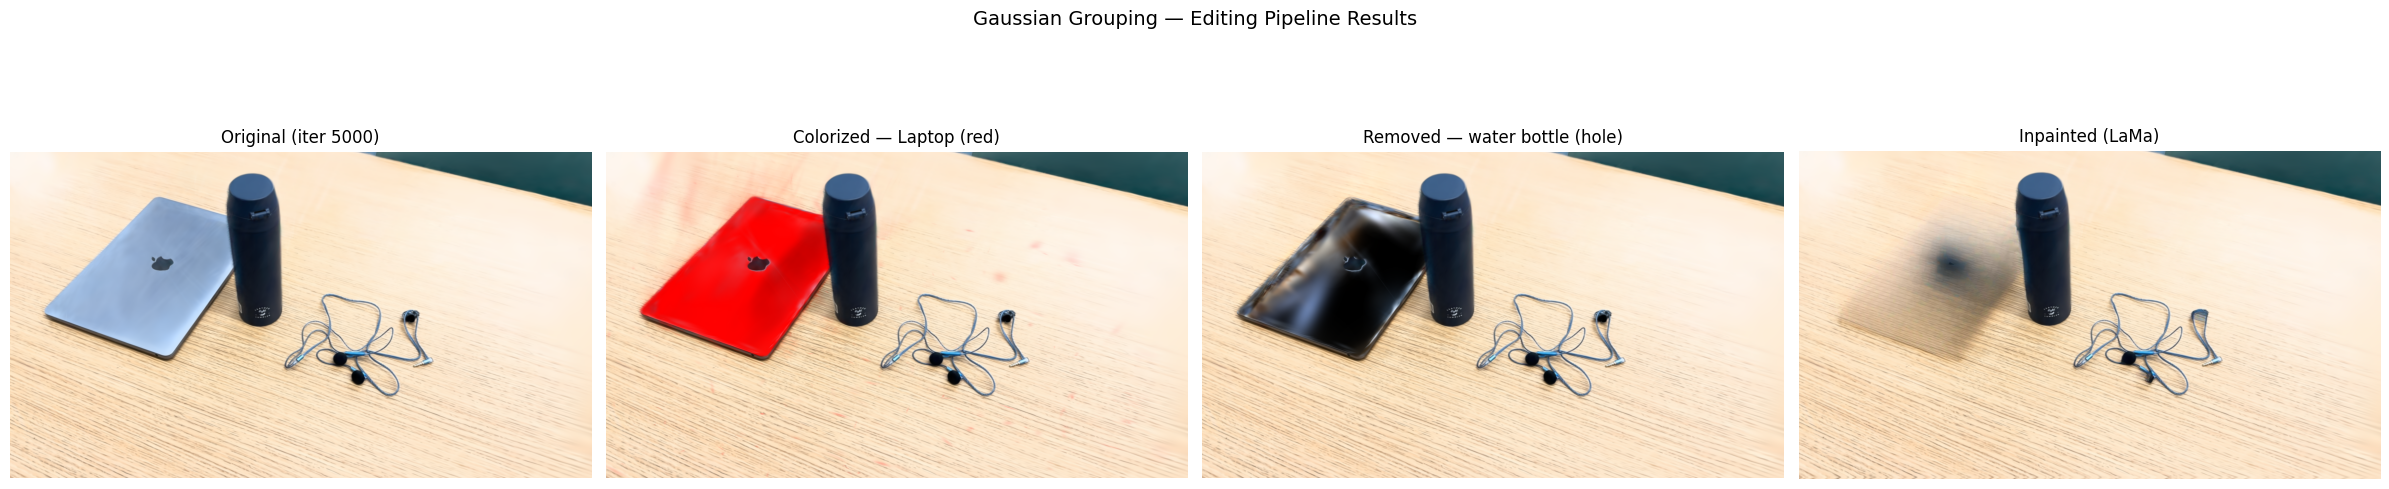

✅ Saved comparison → /content/drive/MyDrive/CS515_FinalProject/results/gg_output/editing_comparison.png


In [56]:
import os, glob as glob_mod
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Change this if a different frame shows the removed object more clearly
FRAME_IDX = 48

def get_frame(d, idx=0):
    imgs = sorted(glob_mod.glob(os.path.join(d, '*.png')))
    if not imgs:
        return None
    return mpimg.imread(imgs[min(idx, len(imgs) - 1)])

orig_dir      = os.path.join(OUTPUT_DIR, 'edited_original',  'renders')
removed_dir   = os.path.join(OUTPUT_DIR, 'edited_removal',   'renders')
inpainted_dir = os.path.join(OUTPUT_DIR, 'edited_inpainted', 'renders')
colorize_dir  = os.path.join(OUTPUT_DIR, 'edited_colorize',  'renders')

orig_img      = get_frame(orig_dir,      FRAME_IDX)
removed_img   = get_frame(removed_dir,   FRAME_IDX)
inpainted_img = get_frame(inpainted_dir, FRAME_IDX)
color_img     = get_frame(colorize_dir,  FRAME_IDX)

# Build whichever panels exist (skip missing folders gracefully)
panels = [
    (orig_img,      'Original (iter 5000)'),
    (color_img,     'Colorized — Laptop (red)'),
    (removed_img,   'Removed — water bottle (hole)'),
    (inpainted_img, 'Inpainted (LaMa)'),
]
panels = [(img, t) for img, t in panels if img is not None]
n = len(panels)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
if n == 1:
    axes = [axes]
fig.suptitle('Gaussian Grouping — Editing Pipeline Results', fontsize=14)

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()

# ── Save to Drive ─────────────────────────────────────────────────────────
out_path = os.path.join(RESULTS_DIR, 'editing_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved comparison → {out_path}')

In [55]:
import os, shutil

print('Backing up edited PLYs and renders to Drive ...')
for sub in ['edited_colorize', 'edited_removal', 'edited_inpainted']:
    src = os.path.join(OUTPUT_DIR, sub)
    dst = os.path.join(RESULTS_DIR, sub)
    if not os.path.exists(src):
        print(f'  ⏭  {sub}: not found locally')
        continue
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    print(f'  ✅ {sub} → Drive')

# Also save the comparison image
comp_local = os.path.join(RESULTS_DIR, 'editing_comparison.png')
if os.path.exists(comp_local):
    print(f'  ✅ editing_comparison.png already in {RESULTS_DIR}')

print('\n=== Final Drive structure ===')
for root, dirs, files in os.walk(PROJECT):
    depth = root.replace(PROJECT, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
print('\n✅ Done — share PROJECT/shared_data/ with your group')

Backing up edited PLYs and renders to Drive ...
  ✅ edited_colorize → Drive
  ✅ edited_removal → Drive
  ✅ edited_inpainted → Drive
  ✅ editing_comparison.png already in /content/drive/MyDrive/CS515_FinalProject/results/gg_output

=== Final Drive structure ===
CS515_FinalProject/
  gaussian-grouping/
    .git/
    Tracking-Anything-with-DEVA/
    arguments/
    config/
    docs/
    ext/
    gaussian_renderer/
    lama/
    media/
    scene/
    script/
    submodules/
    utils/
  Data/
  results/
    my_scene/
    gg_output/
  shared_data/
    frames/
    masks/
    deva_masks/
    sam_visualizations/
    colmap/
  checkpoints/

✅ Done — share PROJECT/shared_data/ with your group


## Step 12 — Side-by-Side Comparison & Save Everything to Drive

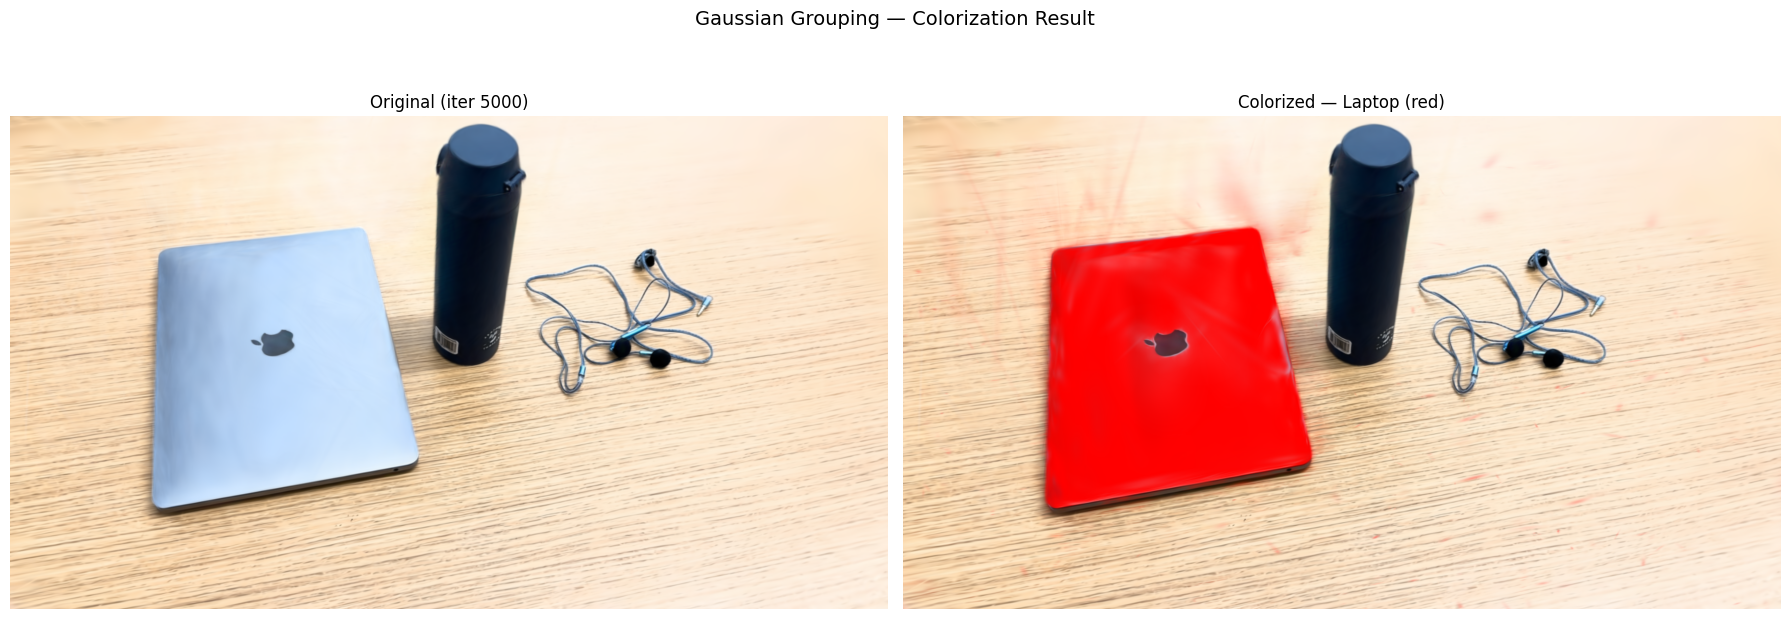

✅ Saved comparison → /content/drive/MyDrive/CS515_FinalProject/results/gg_output/colorize_comparison.png


In [242]:
import os, glob as glob_mod
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

FRAME_IDX = 30   # change this to whichever frame shows the laptop clearly

def get_frame(d, idx=0):
    imgs = sorted(glob_mod.glob(os.path.join(d, '*.png')))
    if not imgs:
        return None
    return mpimg.imread(imgs[min(idx, len(imgs)-1)])

orig_dir     = os.path.join(OUTPUT_DIR, 'edited_original', 'renders')
colorize_dir = os.path.join(OUTPUT_DIR, 'edited_colorize', 'renders')

orig_img  = get_frame(orig_dir,     FRAME_IDX)
color_img = get_frame(colorize_dir, FRAME_IDX)

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Gaussian Grouping — Colorization Result', fontsize=14)

for ax, img, title in zip(axes,
                           [orig_img,  color_img],
                           ['Original (iter 5000)', 'Colorized — Laptop (red)']):
    if img is not None:
        ax.imshow(img)
        ax.set_title(title, fontsize=12)
    else:
        ax.set_title(f'{title} — NOT FOUND', fontsize=12, color='red')
        ax.text(0.5, 0.5, f'Missing:\n{title}',
                ha='center', va='center', transform=ax.transAxes, color='red')
    ax.axis('off')

plt.tight_layout()

# ── Save to Drive ─────────────────────────────────────────────────────────
out_path = os.path.join(RESULTS_DIR, 'colorize_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved comparison → {out_path}')

In [ ]:
import os, shutil

print('Backing up edited PLYs and renders to Drive ...')
for sub in ['edited_colorize', 'edited_removal']:
    src = os.path.join(OUTPUT_DIR, sub)
    dst = os.path.join(RESULTS_DIR, sub)
    if not os.path.exists(src):
        print(f'  ⏭  {sub}: not found locally')
        continue
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
    print(f'  ✅ {sub} → Drive')

# Also save the comparison image
comp_local = os.path.join(RESULTS_DIR, 'editing_comparison.png')
if os.path.exists(comp_local):
    print(f'  ✅ editing_comparison.png already in {RESULTS_DIR}')

print('\n=== Final Drive structure ===')
for root, dirs, files in os.walk(PROJECT):
    depth = root.replace(PROJECT, '').count(os.sep)
    if depth > 2:
        continue
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
print('\n✅ Done — share PROJECT/shared_data/ with your group')

In [57]:
# 13.x — Build a side-by-side comparison video (Original | Colorize | Remove | Inpaint)
import os, glob as glob_mod
import numpy as np
import cv2
from PIL import Image

# ── CONFIG ────────────────────────────────────────────────────────────────
FPS         = 15           # frames per second of the output video
PANEL_H     = 540          # height per panel in pixels (width auto-scales to keep aspect)
LABEL_BAR   = 40           # height of the black label strip above each panel
INCLUDE     = ['original', 'colorize', 'removal', 'inpainted']  # column order
OUT_NAME    = 'comparison_video.mp4'
# ──────────────────────────────────────────────────────────────────────────

# Map each panel name → (folder, display label)
PANEL_DIRS = {
    'original' : (os.path.join(OUTPUT_DIR, 'edited_original',  'renders'), 'Original'),
    'colorize' : (os.path.join(OUTPUT_DIR, 'edited_colorize',  'renders'), 'Colorized (laptop = red)'),
    'removal'  : (os.path.join(OUTPUT_DIR, 'edited_removal',   'renders'), 'Removed (water bottle)'),
    'inpainted': (os.path.join(OUTPUT_DIR, 'edited_inpainted', 'renders'), 'Inpainted (LaMa)'),
}

# Keep only the panels whose folders exist
panels = []
for key in INCLUDE:
    d, label = PANEL_DIRS[key]
    if os.path.isdir(d) and len(glob_mod.glob(os.path.join(d, '*.png'))) > 0:
        panels.append((key, d, label))
        print(f'  ✅ {label:30s} → {d}')
    else:
        print(f'  ⏭  {label:30s} → not found, skipping')

assert len(panels) >= 2, 'Need at least 2 panels to make a comparison video'

# Sorted PNG paths per panel
panel_paths = [sorted(glob_mod.glob(os.path.join(d, '*.png'))) for _, d, _ in panels]

# Use the minimum length so every panel has a frame at every step
n_frames = min(len(p) for p in panel_paths)
print(f'\nBuilding video with {len(panels)} panels × {n_frames} frames @ {FPS} fps ...')

# ── Compute panel dimensions from the first frame of the first panel ──────
sample = np.array(Image.open(panel_paths[0][0]).convert('RGB'))
src_h, src_w = sample.shape[:2]
panel_w = int(round(PANEL_H * src_w / src_h))
total_w = panel_w * len(panels)
total_h = LABEL_BAR + PANEL_H

print(f'Output resolution: {total_w} × {total_h}')

# ── Init writer (mp4v is the most portable codec on Colab) ────────────────
out_path = os.path.join(RESULTS_DIR, OUT_NAME)
fourcc   = cv2.VideoWriter_fourcc(*'mp4v')
writer   = cv2.VideoWriter(out_path, fourcc, FPS, (total_w, total_h))
assert writer.isOpened(), f'Could not open video writer for {out_path}'

# Pre-render the label strip once (it's static across all frames)
label_strip = np.zeros((LABEL_BAR, total_w, 3), dtype=np.uint8)
for col, (_, _, label) in enumerate(panels):
    x0 = col * panel_w
    # Center the label text in its column
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    tx = x0 + (panel_w - tw) // 2
    ty = (LABEL_BAR + th) // 2
    cv2.putText(label_strip, label, (tx, ty),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

# ── Compose each frame and write ──────────────────────────────────────────
for i in range(n_frames):
    cols = []
    for paths in panel_paths:
        img = np.array(Image.open(paths[i]).convert('RGB'))
        if (img.shape[1], img.shape[0]) != (panel_w, PANEL_H):
            img = cv2.resize(img, (panel_w, PANEL_H), interpolation=cv2.INTER_AREA)
        cols.append(img)
    panel_row = np.hstack(cols)                              # H × W*4 × 3, RGB
    full = np.vstack([label_strip, panel_row])               # add label strip on top
    writer.write(cv2.cvtColor(full, cv2.COLOR_RGB2BGR))      # cv2 wants BGR

    if (i + 1) % 25 == 0 or (i + 1) == n_frames:
        print(f'  [{i+1:3d}/{n_frames}] frames written', flush=True)

writer.release()

size_mb = os.path.getsize(out_path) / 1e6
print(f'\n✅ Saved video → {out_path} ({size_mb:.1f} MB)')

# ── Inline preview in the notebook ────────────────────────────────────────
from IPython.display import Video, display
display(Video(out_path, embed=True, width=900))

Output hidden; open in https://colab.research.google.com to view.